<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/FetalWatch_FINAL_V3_RUN_ALL_SAFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — FetalWatch FINAL V3

## Run-All-Safe, Industry-Level Five-Public-Source Google Colab Workflow

This notebook develops the clinic/hospital **FetalWatch** research system.

### Primary deployed output

The primary model classifies 21 validated CTG features into:

- `Normal`
- `Suspicious`
- `Pathological`

### Five automatically accessed public sources

1. **UCI Cardiotocography** — exact expert `NSP` target for the primary classifier.
2. **CTU-UHB** — intrapartum FHR/UC signals and delivery outcomes.
3. **FHRMA** — expert FHR morphology annotations.
4. **NIFEA** — fetal ECG arrhythmia/normal recordings.
5. **ADFECGDB** — abdominal and direct-reference fetal ECG.

Only UCI contains the exact three-class target. Other sources remain separate
auxiliary evidence/validation tasks. No incompatible target labels are invented.

### FINAL V3 reliability corrections

- CTU/FHRMA arrays are always converted to writable NumPy copies.
- `cross_val_predict` is imported and auxiliary CV folds are class-count safe.
- External-source download or schema failure is recorded and skipped instead of
  crashing the complete notebook.
- Empty CTU/FHRMA/NIFEA/ADFECGDB results always receive a valid schema.
- `numpy.trapezoid` replaces removed/deprecated integration calls.
- FHRMA annotations are matched by numeric record ID and audited.
- Weak auxiliary heads remain inactive through explicit validation gates.
- Calibrated OOF probabilities drive the pathological threshold and API decision.
- API range checks, consistency checks, OOD warnings, signal-quality refusal,
  model card, checksums, FastAPI and LangGraph wrappers are included.
- A preflight test catches the original read-only-array bug before CTU processing.

> **Clinical notice:** Research/hackathon prototype only. This is not a certified
> medical device and cannot replace qualified obstetric interpretation.

## 1. Install dependencies

In [1]:
%%capture
!pip install -U \
  "pandas>=2.2,<4.0" "numpy>=1.26,<3.0" "scipy>=1.13" \
  "matplotlib>=3.8" "scikit-learn==1.9.0" \
  "xgboost>=3.0,<4.0" "lightgbm>=4.5,<5.0" \
  "ucimlrepo>=0.0.7" "wfdb>=4.2" "pyedflib>=0.1.40" \
  "requests>=2.32" "joblib>=1.4" "pyarrow>=16.0" \
  "fastapi>=0.115" "uvicorn>=0.34" "pydantic>=2.10"

## 2. Imports and configuration

In [1]:
from __future__ import annotations

import hashlib
import json
import random
import re
import shutil
import sys
import tarfile
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Mapping

import joblib
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyedflib
import requests
import sklearn
import wfdb
import xgboost

from lightgbm import LGBMClassifier
from scipy.signal import butter, filtfilt, find_peaks, periodogram
from scipy.stats import entropy, kurtosis, randint, loguniform, skew, spearmanr, uniform
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.utils.validation import has_fit_parameter
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 42
FAST_MODE = True
CV_SPLITS = 5
TUNING_ITERATIONS = 12 if FAST_MODE else 40
BOOTSTRAP_ITERATIONS = 400 if FAST_MODE else 2000
TARGET_PATHOLOGICAL_RECALL = 0.92
MODEL_VERSION = '3.0.0'
MAX_HIGH_RATE_SECONDS = 300
CTU_ACIDEMIA_PH_THRESHOLD = 7.15

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path('/content/fetalwatch_final_v3')
RAW_DIR = ROOT / 'raw'
EXTRACTED_DIR = ROOT / 'extracted'
PROCESSED_DIR = ROOT / 'processed'
ARTIFACT_DIR = ROOT / 'artifacts'

for directory in [RAW_DIR, EXTRACTED_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

EXTERNAL_STAGE_STATUS: dict[str, dict[str, Any]] = {}

print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('scikit-learn:', sklearn.__version__)
print('XGBoost:', xgboost.__version__)
print('LightGBM:', lightgbm.__version__)
print('Project root:', ROOT)

Python: 3.12.13
pandas: 3.0.3
NumPy: 2.5.1
scikit-learn: 1.9.0
XGBoost: 3.3.0
LightGBM: 4.7.0
Project root: /content/fetalwatch_final_v3


## 3. Source registry

In [2]:
SOURCE_REGISTRY = {
    "uci_cardio": {
        "role": "primary_supervised_three_class",
        "repository_id": 193,
    },
    "ctu_uhb": {
        "role": "auxiliary_acidemia_and_external_ctg_validation",
        "zenodo_record": "19510407",
    },
    "fhrma": {
        "role": "expert_morphology_validation",
        "zenodo_record": "19510407",
    },
    "nifea": {
        "role": "auxiliary_arrhythmia_evidence",
        "physionet_path": "nifeadb/1.0.0",
    },
    "adfecgdb": {
        "role": "direct_reference_signal_quality_validation",
        "physionet_path": "adfecgdb/1.0.0",
    },
}
display(pd.DataFrame(SOURCE_REGISTRY).T)

,role,repository_id,zenodo_record,physionet_path
uci_cardio,primary_supervised_three_class,193,NaN,NaN
ctu_uhb,auxiliary_acidemia_and_external_ctg_validation,NaN,19510407,NaN
fhrma,expert_morphology_validation,NaN,19510407,NaN
nifea,auxiliary_arrhythmia_evidence,NaN,NaN,nifeadb/1.0.0
adfecgdb,direct_reference_signal_quality_validation,NaN,NaN,adfecgdb/1.0.0


## 4. Download helpers

In [3]:
def request_with_retries(
    url: str,
    *,
    stream: bool = False,
    timeout: int = 300,
    attempts: int = 3,
) -> requests.Response:
    last_error: Exception | None = None

    for attempt in range(1, attempts + 1):
        try:
            response = requests.get(
                url,
                stream=stream,
                timeout=timeout,
                headers={'User-Agent': 'MaaHifazat-FetalWatch/3.0'},
            )
            response.raise_for_status()
            return response
        except Exception as error:
            last_error = error
            print(f'Download attempt {attempt}/{attempts} failed:', repr(error))

    raise RuntimeError(f'All download attempts failed for {url}: {last_error!r}')


def stream_download(
    url: str,
    output_path: Path,
    expected_md5: str | None = None,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        if expected_md5:
            digest = hashlib.md5(output_path.read_bytes()).hexdigest()
            if digest.lower() == expected_md5.lower():
                print('Already downloaded and checksum verified:', output_path.name)
                return output_path
            output_path.unlink(missing_ok=True)
        else:
            print('Already downloaded:', output_path.name)
            return output_path

    response = request_with_retries(url, stream=True)
    temporary_path = output_path.with_suffix(output_path.suffix + '.part')

    with temporary_path.open('wb') as file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)

    temporary_path.replace(output_path)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            output_path.unlink(missing_ok=True)
            raise ValueError(f'Checksum mismatch for {output_path.name}: {digest}')

    return output_path


def download_zenodo_file(record_id: str, filename: str) -> Path:
    response = request_with_retries(
        f'https://zenodo.org/api/records/{record_id}',
        timeout=90,
    )
    metadata = response.json()

    item = next(
        (entry for entry in metadata.get('files', []) if entry.get('key') == filename),
        None,
    )

    if item is None:
        available = [entry.get('key') for entry in metadata.get('files', [])]
        raise FileNotFoundError(f'{filename} not found. Available: {available}')

    url = item.get('links', {}).get('content') or item.get('links', {}).get('self')
    checksum = item.get('checksum', '')
    expected_md5 = checksum.split(':', 1)[1] if checksum.startswith('md5:') else None

    return stream_download(url, RAW_DIR / filename, expected_md5)


def safe_extract_tar(archive_path: Path, destination: Path) -> Path:
    destination.mkdir(parents=True, exist_ok=True)

    marker = destination / '.extraction_complete'
    if marker.exists():
        return destination

    with tarfile.open(archive_path, 'r:*') as archive:
        destination_root = destination.resolve()

        for member in archive.getmembers():
            target = (destination / member.name).resolve()
            try:
                target.relative_to(destination_root)
            except ValueError as error:
                raise ValueError(f'Unsafe archive path: {member.name}') from error

        archive.extractall(destination)

    marker.write_text('ok', encoding='utf-8')
    return destination


def download_text(url: str) -> str:
    return request_with_retries(url, timeout=90).text

## 5. Automatically download CTU-UHB and FHRMA

In [4]:
CTGDL_RECORD_ID = '19510407'
CTGDL_FILES = {
    'ctu_processed': 'CTGDL_ctu_uhb_proc_csv.tar.gz',
    'ctu_metadata': 'ctu_uhb_metadata.csv',
    'fhrma_processed': 'CTGDL_FHRMA_proc_csv.tar.gz',
    'fhrma_annotations': 'CTGDL_FHRMA_ano_csv.tar.gz',
    'fhrma_metadata': 'CTGDL_FHEMA_metadata.csv',
}

ctu_signal_root = EXTRACTED_DIR / 'ctu_uhb'
fhrma_signal_root = EXTRACTED_DIR / 'fhrma_signals'
fhrma_annotation_root = EXTRACTED_DIR / 'fhrma_annotations'
ctu_metadata_raw = pd.DataFrame()
fhrma_metadata_raw = pd.DataFrame()

try:
    ctgdl_paths = {
        key: download_zenodo_file(CTGDL_RECORD_ID, filename)
        for key, filename in CTGDL_FILES.items()
    }

    ctu_signal_root = safe_extract_tar(
        ctgdl_paths['ctu_processed'],
        ctu_signal_root,
    )
    fhrma_signal_root = safe_extract_tar(
        ctgdl_paths['fhrma_processed'],
        fhrma_signal_root,
    )
    fhrma_annotation_root = safe_extract_tar(
        ctgdl_paths['fhrma_annotations'],
        fhrma_annotation_root,
    )

    ctu_metadata_raw = pd.read_csv(
        ctgdl_paths['ctu_metadata'],
        low_memory=False,
    )
    fhrma_metadata_raw = pd.read_csv(
        ctgdl_paths['fhrma_metadata'],
        low_memory=False,
    )

    EXTERNAL_STAGE_STATUS['ctgdl_download'] = {
        'status': 'success',
        'ctu_metadata_rows': int(len(ctu_metadata_raw)),
        'fhrma_metadata_rows': int(len(fhrma_metadata_raw)),
    }
except Exception as error:
    EXTERNAL_STAGE_STATUS['ctgdl_download'] = {
        'status': 'skipped_after_error',
        'error': repr(error),
    }
    print('CTGDL stage was skipped:', repr(error))

print('CTU metadata shape:', ctu_metadata_raw.shape)
print('FHRMA metadata shape:', fhrma_metadata_raw.shape)

CTU metadata shape: (552, 42)
FHRMA metadata shape: (135, 16)


## 6. Load UCI Cardiotocography

In [5]:
from ucimlrepo import fetch_ucirepo

UCI_RAW_FEATURES = [
    "LB", "AC", "FM", "UC", "DL", "DS", "DP",
    "ASTV", "MSTV", "ALTV", "MLTV",
    "Width", "Min", "Max", "Nmax", "Nzeros",
    "Mode", "Mean", "Median", "Variance", "Tendency",
]

ID_TO_LABEL = {0: "normal", 1: "suspicious", 2: "pathological"}
PATHOLOGICAL_ID = 2


def load_uci_cardio() -> tuple[pd.DataFrame, pd.Series]:
    dataset = fetch_ucirepo(id=193)
    features = dataset.data.features.copy()
    targets = dataset.data.targets.copy()
    features.columns = [str(c).strip() for c in features.columns]

    if isinstance(targets, pd.Series):
        target_series = targets
    elif "NSP" in targets.columns:
        target_series = targets["NSP"]
    elif "NSP" in features.columns:
        target_series = features.pop("NSP")
    else:
        matching = [c for c in targets.columns if str(c).strip().upper() == "NSP"]
        if not matching:
            raise ValueError(f"NSP target not found: {targets.columns.tolist()}")
        target_series = targets[matching[0]]

    missing = [f for f in UCI_RAW_FEATURES if f not in features.columns]
    if missing:
        raise ValueError(f"Missing UCI features: {missing}")

    X = features[UCI_RAW_FEATURES].apply(pd.to_numeric, errors="coerce")
    labels = target_series.astype(str).str.strip().str.lower()
    label_map = {
        "1": 0, "n": 0, "normal": 0,
        "2": 1, "s": 1, "suspect": 1, "suspicious": 1,
        "3": 2, "p": 2, "pathologic": 2, "pathological": 2,
    }
    y = labels.map(label_map)
    if y.isna().any():
        raise ValueError(f"Unmapped NSP labels: {labels[y.isna()].unique().tolist()}")
    return X.reset_index(drop=True), y.astype(int).reset_index(drop=True)


X_uci_raw, y_uci = load_uci_cardio()
print("UCI:", X_uci_raw.shape)
display(y_uci.map(ID_TO_LABEL).value_counts().to_frame("count"))

UCI: (2126, 21)


,count
NSP,
normal,1655
suspicious,295
pathological,176


## 7. Validate and group duplicate UCI records

In [6]:
UCI_SANITY_BOUNDS = {
    "LB": (50, 220), "AC": (0, 1), "FM": (0, 1), "UC": (0, 1),
    "DL": (0, 1), "DS": (0, 1), "DP": (0, 1),
    "ASTV": (0, 100), "MSTV": (0, 20),
    "ALTV": (0, 100), "MLTV": (0, 100),
    "Width": (0, 250), "Min": (30, 240), "Max": (50, 260),
    "Nmax": (0, 50), "Nzeros": (0, 50),
    "Mode": (30, 240), "Mean": (30, 240), "Median": (30, 240),
    "Variance": (0, 500), "Tendency": (-1, 1),
}

for feature, (lower, upper) in UCI_SANITY_BOUNDS.items():
    invalid = X_uci_raw[feature].notna() & ~X_uci_raw[feature].between(lower, upper)
    X_uci_raw.loc[invalid, feature] = np.nan

signatures = pd.util.hash_pandas_object(
    X_uci_raw.round(10).astype(str), index=False
).astype(str)

label_counts = (
    pd.DataFrame({"signature": signatures, "target": y_uci})
    .groupby("signature")["target"]
    .nunique()
)
ambiguous = set(label_counts[label_counts > 1].index)

keep = ~signatures.isin(ambiguous)
X_uci = X_uci_raw.loc[keep].reset_index(drop=True)
y_uci_clean = y_uci.loc[keep].reset_index(drop=True)
groups_uci = signatures.loc[keep].reset_index(drop=True)

print("Rows after ambiguous-signature removal:", len(X_uci))
print("Unique signatures:", groups_uci.nunique())

Rows after ambiguous-signature removal: 2122
Unique signatures: 2109


## 8. Portable feature engineering

In [7]:
%%writefile fetalwatch_tabular_features.py
from __future__ import annotations
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

RAW_FEATURES = (
    "LB","AC","FM","UC","DL","DS","DP","ASTV","MSTV","ALTV","MLTV",
    "Width","Min","Max","Nmax","Nzeros","Mode","Mean","Median",
    "Variance","Tendency",
)

class FetalWatchFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, raw_features=RAW_FEATURES):
        self.raw_features = raw_features

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(list(self.raw_features), dtype=object)
        return self

    def transform(self, X):
        columns = list(self.raw_features)
        frame = (
            X.reindex(columns=columns).copy()
            if isinstance(X, pd.DataFrame)
            else pd.DataFrame(X, columns=columns)
        )
        frame = frame.apply(pd.to_numeric, errors="coerce")
        eps = 1e-8

        frame["TotalDecelerationRate"] = frame["DL"] + frame["DS"] + frame["DP"]
        frame["SevereDecelerationBurden"] = frame["DS"] + 2 * frame["DP"]
        frame["AccelerationDecelerationBalance"] = (
            frame["AC"] - frame["TotalDecelerationRate"]
        )
        frame["ActivityRate"] = frame["FM"] + frame["UC"]
        frame["AccelerationToContractionRatio"] = frame["AC"] / (frame["UC"].abs() + eps)
        frame["DecelerationToContractionRatio"] = (
            frame["TotalDecelerationRate"] / (frame["UC"].abs() + eps)
        )
        frame["VariabilityComposite"] = frame["MSTV"] + frame["MLTV"]
        frame["AbnormalVariabilityBurden"] = frame["ASTV"] + frame["ALTV"]
        frame["HistogramRangeCheck"] = frame["Max"] - frame["Min"]
        frame["CenterSpread"] = (
            (frame["Mean"] - frame["Median"]).abs()
            + (frame["Median"] - frame["Mode"]).abs()
        )
        frame["BaselineMeanDifference"] = frame["LB"] - frame["Mean"]
        frame["BaselineMedianDifference"] = frame["LB"] - frame["Median"]
        frame["VarianceLog1p"] = np.log1p(frame["Variance"].clip(lower=0))
        frame["PeakDensityProxy"] = frame["Nmax"] / (frame["Width"].abs() + eps)
        frame["ZeroPeakRatio"] = frame["Nzeros"] / (frame["Nmax"].abs() + 1)
        frame["ASTV_MSTV_Interaction"] = frame["ASTV"] * frame["MSTV"]
        frame["ALTV_MLTV_Interaction"] = frame["ALTV"] * frame["MLTV"]
        frame["DecelerationVarianceInteraction"] = (
            frame["TotalDecelerationRate"] * frame["VarianceLog1p"]
        )
        return frame

Writing fetalwatch_tabular_features.py


In [8]:
from sklearn.base import clone
from fetalwatch_tabular_features import FetalWatchFeatureEngineer

engineer = FetalWatchFeatureEngineer()
clone(engineer)
preview = engineer.fit_transform(X_uci.head())
assert preview.shape[1] > len(UCI_RAW_FEATURES)
print("Feature engineering smoke test passed:", preview.shape)

Feature engineering smoke test passed: (5, 39)


## 9. Duplicate- and class-balanced weights

In [9]:
def calculate_uci_weights(targets: pd.Series, groups: pd.Series) -> np.ndarray:
    table = pd.DataFrame({
        "target": targets.reset_index(drop=True),
        "group": groups.reset_index(drop=True),
    })
    duplicate_weight = 1.0 / table.groupby("group")["group"].transform("size").astype(float)
    effective = (
        pd.DataFrame({"target": table["target"], "w": duplicate_weight})
        .groupby("target")["w"]
        .sum()
    )
    weights = np.array([
        duplicate_weight.iloc[i] / float(effective.loc[target])
        for i, target in enumerate(table["target"])
    ])
    return weights / weights.mean()

## 10. Group-safe held-out split

In [10]:
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(outer.split(X_uci, y_uci_clean, groups=groups_uci))

X_train = X_uci.iloc[train_idx].reset_index(drop=True)
X_test = X_uci.iloc[test_idx].reset_index(drop=True)
y_train = y_uci_clean.iloc[train_idx].reset_index(drop=True)
y_test = y_uci_clean.iloc[test_idx].reset_index(drop=True)
groups_train = groups_uci.iloc[train_idx].reset_index(drop=True)
groups_test = groups_uci.iloc[test_idx].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))
display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index=ID_TO_LABEL))

,train,test
NSP,,
normal,1323,330
suspicious,234,59
pathological,140,36


## 11. Candidate models

In [11]:
tree_preprocessor = Pipeline([
    ("features", FetalWatchFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])
neural_preprocessor = Pipeline([
    ("features", FetalWatchFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
])

CANDIDATE_MODELS = {
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600, min_samples_leaf=2,
            random_state=SEED, n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="multi:softprob", num_class=3, eval_metric="mlogloss",
            n_estimators=500, max_depth=4, learning_rate=0.04,
            min_child_weight=2, subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.01, reg_lambda=3.0, random_state=SEED,
            tree_method="hist", n_jobs=1,
        )),
    ]),
    "lightgbm": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", LGBMClassifier(
            objective="multiclass", num_class=3, n_estimators=500,
            learning_rate=0.04, num_leaves=31, random_state=SEED,
            n_jobs=1, verbosity=-1,
        )),
    ]),
    "multilayer_perceptron": Pipeline([
        ("preprocess", neural_preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=1e-3,
            learning_rate_init=1e-3, early_stopping=True,
            validation_fraction=0.15, max_iter=600, random_state=SEED,
        )),
    ]),
}

## 12. Safety-focused metrics

In [12]:
def pathological_recall(y_true, y_pred, sample_weight=None):
    return recall_score(
        y_true, y_pred, labels=[2], average="macro",
        sample_weight=sample_weight, zero_division=0,
    )

def pathological_precision(y_true, y_pred, sample_weight=None):
    return precision_score(
        y_true, y_pred, labels=[2], average="macro",
        sample_weight=sample_weight, zero_division=0,
    )

def safety_score(y_true, y_pred, sample_weight=None):
    recall = pathological_recall(y_true, y_pred, sample_weight)
    macro = f1_score(
        y_true, y_pred, average="macro",
        sample_weight=sample_weight, zero_division=0,
    )
    balanced = balanced_accuracy_score(y_true, y_pred, sample_weight=sample_weight)
    return 0.60 * recall + 0.30 * macro + 0.10 * balanced

def multiclass_metrics(y_true, pred, prob, sample_weight=None):
    return {
        "safety": safety_score(y_true, pred, sample_weight),
        "accuracy": accuracy_score(y_true, pred, sample_weight=sample_weight),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, pred, sample_weight=sample_weight
        ),
        "macro_f1": f1_score(
            y_true, pred, average="macro",
            sample_weight=sample_weight, zero_division=0,
        ),
        "pathological_recall": pathological_recall(y_true, pred, sample_weight),
        "pathological_precision": pathological_precision(y_true, pred, sample_weight),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro",
            sample_weight=sample_weight, labels=[0, 1, 2],
        ),
        "log_loss": log_loss(
            y_true, prob, labels=[0, 1, 2], sample_weight=sample_weight
        ),
    }

## 13. Weighted cross-validation benchmark

In [13]:
inner = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
CV_SPLITS_LIST = list(inner.split(X_train, y_train, groups=groups_train))

def fit_weighted(estimator, X, y, groups):
    weights = calculate_uci_weights(y, groups)
    model = clone(estimator)
    final_estimator = model.named_steps["model"]

    if has_fit_parameter(final_estimator, "sample_weight"):
        model.fit(
            X,
            y,
            model__sample_weight=weights,
        )
    else:
        # Compatibility fallback for estimators without sample_weight.
        # Weighted bootstrap keeps the benchmark runnable and explicit.
        rng = np.random.default_rng(SEED)
        probabilities = weights / weights.sum()
        sampled_indices = rng.choice(
            np.arange(len(y)),
            size=len(y),
            replace=True,
            p=probabilities,
        )
        model.fit(
            X.iloc[sampled_indices],
            y.iloc[sampled_indices],
        )

    return model

def evaluate_cv(estimator):
    rows = []
    for fold, (fit_idx, val_idx) in enumerate(CV_SPLITS_LIST, 1):
        model = fit_weighted(
            estimator,
            X_train.iloc[fit_idx], y_train.iloc[fit_idx],
            groups_train.iloc[fit_idx],
        )
        prob = model.predict_proba(X_train.iloc[val_idx])
        pred = np.argmax(prob, axis=1)
        weights = calculate_uci_weights(
            y_train.iloc[val_idx], groups_train.iloc[val_idx]
        )
        metrics = multiclass_metrics(y_train.iloc[val_idx], pred, prob, weights)
        metrics["fold"] = fold
        rows.append(metrics)
    return pd.DataFrame(rows)

benchmark_rows = []
for name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", name)
    report = evaluate_cv(estimator)
    report.to_csv(ARTIFACT_DIR / f"cv_{name}.csv", index=False)
    benchmark_rows.append({
        "model": name,
        **{f"mean_{c}": report[c].mean() for c in [
            "safety", "macro_f1", "balanced_accuracy",
            "pathological_recall", "pathological_precision",
            "roc_auc_ovr_macro",
        ]},
    })

benchmark = pd.DataFrame(benchmark_rows).sort_values(
    ["mean_safety", "mean_roc_auc_ovr_macro"], ascending=False
).reset_index(drop=True)
display(benchmark.round(4))
benchmark.to_csv(ARTIFACT_DIR / "primary_model_benchmark.csv", index=False)

Evaluating: random_forest
Evaluating: xgboost
Evaluating: lightgbm
Evaluating: multilayer_perceptron


,model,mean_safety,mean_macro_f1,mean_balanced_accuracy,mean_pathological_recall,mean_pathological_precision,mean_roc_auc_ovr_macro
0,xgboost,0.9227,0.9151,0.9154,0.9278,0.9697,0.9860
1,lightgbm,0.9098,0.9045,0.9051,0.9132,0.9714,0.9849
2,random_forest,0.9046,0.9020,0.9019,0.9063,0.9586,0.9832
3,multilayer_perceptron,0.8198,0.8195,0.8194,0.8201,0.8432,0.9084


## 14. Custom weighted hyperparameter tuning

In [14]:
best_family = benchmark.iloc[0]["model"]
base_estimator = CANDIDATE_MODELS[best_family]

PARAMETER_SPACES = {
    "random_forest": {
        "model__n_estimators": randint(350, 1000),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 18),
        "model__min_samples_leaf": randint(1, 8),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 900),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__min_child_weight": randint(1, 10),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
        "model__gamma": uniform(0.0, 1.0),
    },
    "lightgbm": {
        "model__n_estimators": randint(250, 900),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__num_leaves": randint(15, 96),
        "model__max_depth": [-1, 4, 6, 8, 12, 16],
        "model__min_child_samples": randint(10, 80),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
    },
    "multilayer_perceptron": {
        "model__hidden_layer_sizes": [
            (64,), (96,), (128,), (96, 48),
            (128, 64), (128, 64, 32),
        ],
        "model__alpha": loguniform(1e-5, 1e-1),
        "model__learning_rate_init": loguniform(1e-4, 5e-3),
        "model__activation": ["relu", "tanh"],
    },
}

parameter_candidates = list(ParameterSampler(
    PARAMETER_SPACES[best_family],
    n_iter=TUNING_ITERATIONS,
    random_state=SEED,
))

tuning_rows = []

for number, parameters in enumerate(parameter_candidates, 1):
    print(f"Candidate {number}/{len(parameter_candidates)}")
    estimator = clone(base_estimator).set_params(**parameters)
    report = evaluate_cv(estimator)
    tuning_rows.append({
        "candidate": number,
        "parameters": parameters,
        **{f"mean_{c}": report[c].mean() for c in [
            "safety", "macro_f1", "balanced_accuracy",
            "pathological_recall", "pathological_precision",
            "roc_auc_ovr_macro",
        ]},
        "std_safety": report["safety"].std(),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["mean_safety", "mean_roc_auc_ovr_macro", "std_safety"],
    ascending=[False, False, True],
).reset_index(drop=True)

best_parameters = tuning_results.iloc[0]["parameters"]
best_estimator = clone(base_estimator).set_params(**best_parameters)

print("Selected family:", best_family)
print(json.dumps(best_parameters, indent=2, default=str))
display(tuning_results.head(10))

tuning_export = tuning_results.copy()
tuning_export["parameters"] = tuning_export["parameters"].map(
    lambda value: json.dumps(value, default=str)
)
tuning_export.to_csv(
    ARTIFACT_DIR / "primary_weighted_tuning.csv",
    index=False,
)

Candidate 1/12
Candidate 2/12
Candidate 3/12
Candidate 4/12
Candidate 5/12
Candidate 6/12
Candidate 7/12
Candidate 8/12
Candidate 9/12
Candidate 10/12
Candidate 11/12
Candidate 12/12
Selected family: xgboost
{
  "model__colsample_bytree": 0.7465997137078901,
  "model__gamma": 0.2962735057040824,
  "model__learning_rate": 0.016406549192101497,
  "model__max_depth": 2,
  "model__min_child_weight": 7,
  "model__n_estimators": 770,
  "model__reg_alpha": 0.12407740046553102,
  "model__reg_lambda": 0.27065961369409125,
  "model__subsample": 0.6519327409932608
}


,candidate,parameters,mean_safety,mean_macro_f1,mean_balanced_accuracy,mean_pathological_recall,mean_pathological_precision,mean_roc_auc_ovr_macro,std_safety
0,9,{'model__colsample_bytree': 0.7465997137078901...,0.933371,0.919979,0.919805,0.942328,0.963506,0.983016,0.018408
1,8,{'model__colsample_bytree': 0.6809723757181718...,0.931757,0.915944,0.915774,0.942328,0.966407,0.983937,0.018692
2,11,{'model__colsample_bytree': 0.8681543443896453...,0.931491,0.926326,0.926413,0.934921,0.971898,0.985024,0.026093
3,6,{'model__colsample_bytree': 0.6927133821956726...,0.930801,0.924183,0.924347,0.935185,0.969927,0.986932,0.012445
4,12,{'model__colsample_bytree': 0.7840244061638264...,0.930723,0.924037,0.924005,0.935185,0.967633,0.985480,0.012344
5,1,{'model__colsample_bytree': 0.7810890415965769...,0.929925,0.921994,0.922157,0.935185,0.964965,0.985893,0.010639
6,5,{'model__colsample_bytree': 0.8881076385057229...,0.927771,0.905978,0.905808,0.942328,0.963944,0.978784,0.017514
7,7,{'model__colsample_bytree': 0.8413485977701479...,0.926199,0.923804,0.923913,0.927778,0.963741,0.984083,0.021574
8,4,{'model__colsample_bytree': 0.9908144315945107...,0.924420,0.919396,0.919346,0.927778,0.972827,0.985550,0.019647
9,10,"{'model__colsample_bytree': 0.935411499959192,...",0.919956,0.918949,0.918905,0.920635,0.965085,0.983042,0.022808


## 15. Out-of-fold probabilities and multiclass calibration

In [15]:
def generate_oof_probabilities(estimator):
    probabilities = np.full((len(X_train), 3), np.nan)
    for fit_idx, val_idx in CV_SPLITS_LIST:
        model = fit_weighted(
            estimator,
            X_train.iloc[fit_idx], y_train.iloc[fit_idx],
            groups_train.iloc[fit_idx],
        )
        probabilities[val_idx] = model.predict_proba(X_train.iloc[val_idx])
    if np.isnan(probabilities).any():
        raise RuntimeError("Incomplete OOF probabilities.")
    return probabilities

def probability_to_logit(probabilities):
    clipped = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)

def fit_multiclass_calibrators(raw_probabilities, targets, weights):
    calibrators = []
    for class_id in [0, 1, 2]:
        binary = (targets.to_numpy() == class_id).astype(int)
        calibrator = LogisticRegression(
            C=1e6, solver="lbfgs", max_iter=3000, random_state=SEED
        )
        calibrator.fit(
            probability_to_logit(raw_probabilities[:, class_id]),
            binary,
            sample_weight=weights,
        )
        calibrators.append(calibrator)
    return calibrators

def apply_multiclass_calibrators(calibrators, raw_probabilities):
    columns = []
    for class_id, calibrator in enumerate(calibrators):
        columns.append(
            calibrator.predict_proba(
                probability_to_logit(raw_probabilities[:, class_id])
            )[:, 1]
        )
    calibrated = np.column_stack(columns)
    return calibrated / np.clip(calibrated.sum(axis=1, keepdims=True), 1e-12, None)

oof_raw_probabilities = generate_oof_probabilities(best_estimator)
oof_weights = calculate_uci_weights(y_train, groups_train)
class_calibrators = fit_multiclass_calibrators(
    oof_raw_probabilities, y_train, oof_weights
)
oof_calibrated_probabilities = apply_multiclass_calibrators(
    class_calibrators, oof_raw_probabilities
)

assert np.allclose(oof_calibrated_probabilities.sum(axis=1), 1.0)
print("OOF calibration complete.")

OOF calibration complete.


## 16. Optimize pathological threshold

In [16]:
def apply_pathological_threshold(probabilities, threshold):
    predictions = np.argmax(probabilities, axis=1).astype(int)
    predictions[probabilities[:, 2] >= threshold] = 2
    return predictions

threshold_rows = []

for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred = apply_pathological_threshold(oof_calibrated_probabilities, threshold)
    metrics = multiclass_metrics(
        y_train, pred, oof_calibrated_probabilities, oof_weights
    )
    threshold_rows.append({"threshold": float(threshold), **metrics})

threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table[
    threshold_table["pathological_recall"] >= TARGET_PATHOLOGICAL_RECALL
]

if not eligible.empty:
    selected = eligible.sort_values(
        ["macro_f1", "pathological_precision", "balanced_accuracy", "threshold"],
        ascending=[False, False, False, False],
    ).iloc[0]
else:
    selected = threshold_table.sort_values(
        ["pathological_recall", "macro_f1", "pathological_precision"],
        ascending=False,
    ).iloc[0]

PATHOLOGICAL_THRESHOLD = float(selected["threshold"])
print("Selected pathological threshold:", PATHOLOGICAL_THRESHOLD)
display(selected.to_frame("value"))
threshold_table.to_csv(
    ARTIFACT_DIR / "pathological_threshold_analysis.csv",
    index=False,
)

Selected pathological threshold: 0.95


,value
threshold,0.950000
safety,0.932927
accuracy,0.918520
balanced_accuracy,0.918520
macro_f1,0.918691
pathological_recall,0.942446
pathological_precision,0.959636
roc_auc_ovr_macro,0.982872
log_loss,0.234441


## 17. Held-out primary-model evaluation

In [17]:
primary_model = fit_weighted(best_estimator, X_train, y_train, groups_train)

raw_test_probabilities = primary_model.predict_proba(X_test)
calibrated_test_probabilities = apply_multiclass_calibrators(
    class_calibrators, raw_test_probabilities
)
test_predictions = apply_pathological_threshold(
    calibrated_test_probabilities, PATHOLOGICAL_THRESHOLD
)

test_weights = calculate_uci_weights(y_test, groups_test)

unweighted_test_metrics = multiclass_metrics(
    y_test, test_predictions, calibrated_test_probabilities
)
weighted_test_metrics = multiclass_metrics(
    y_test, test_predictions, calibrated_test_probabilities, test_weights
)

print("Unweighted:")
print(json.dumps(unweighted_test_metrics, indent=2))
print("\nDuplicate/class-balanced:")
print(json.dumps(weighted_test_metrics, indent=2))
print("\nClassification report:")
print(classification_report(
    y_test, test_predictions,
    target_names=["normal", "suspicious", "pathological"],
    zero_division=0,
))

Unweighted:
{
  "safety": 0.9681858828265901,
  "accuracy": 0.9294117647058824,
  "balanced_accuracy": 0.9650573531929464,
  "macro_f1": 0.9056004916909853,
  "pathological_recall": 1.0,
  "pathological_precision": 0.9,
  "roc_auc_ovr_macro": 0.9927037891974498,
  "log_loss": 0.2040141789181665
}

Duplicate/class-balanced:
{
  "safety": 0.9858575994338452,
  "accuracy": 0.9647886107223691,
  "balanced_accuracy": 0.9647886107223692,
  "macro_f1": 0.9645957945386944,
  "pathological_recall": 1.0,
  "pathological_precision": 0.9879154078549848,
  "roc_auc_ovr_macro": 0.9950190627573616,
  "log_loss": 0.12646282386387617
}

Classification report:
              precision    recall  f1-score   support

      normal       1.00      0.91      0.95       330
  suspicious       0.70      0.98      0.82        59
pathological       0.90      1.00      0.95        36

    accuracy                           0.93       425
   macro avg       0.87      0.97      0.91       425
weighted avg       0.95

<Figure size 700x600 with 0 Axes>

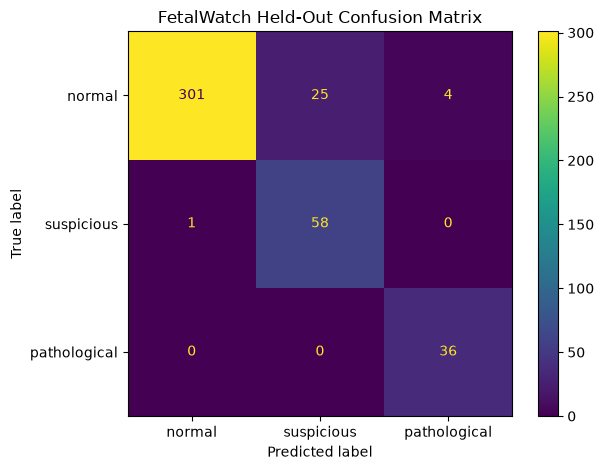

In [18]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1, 2],
    display_labels=["normal", "suspicious", "pathological"],
    values_format="d",
)
plt.title("FetalWatch Held-Out Confusion Matrix")
plt.tight_layout()
plt.show()

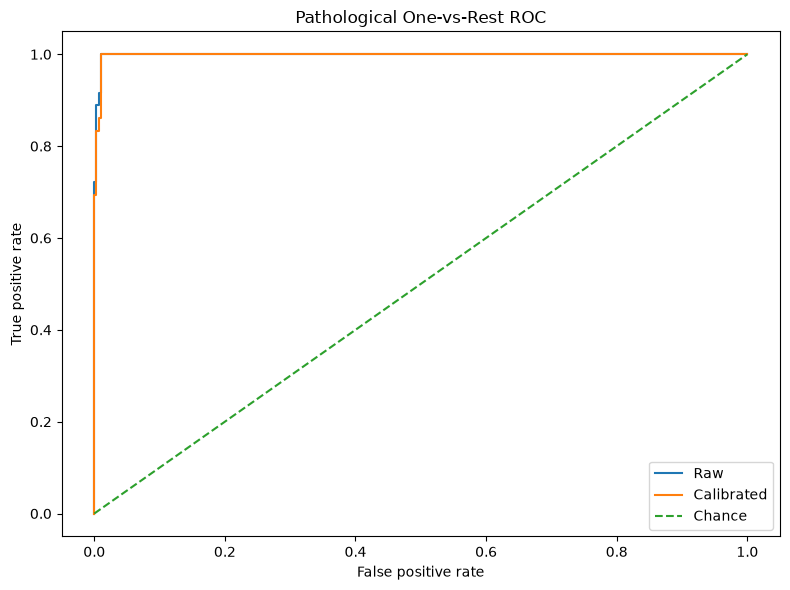

In [19]:
pathological_binary = (y_test.to_numpy() == 2).astype(int)

plt.figure(figsize=(8, 6))
for name, probabilities in {
    "Raw": raw_test_probabilities[:, 2],
    "Calibrated": calibrated_test_probabilities[:, 2],
}.items():
    fpr, tpr, _ = roc_curve(pathological_binary, probabilities)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.title("Pathological One-vs-Rest ROC")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

## 17B. False-negative audit, bootstrap confidence intervals, and feature importance

In [20]:
heldout_predictions = X_test.copy()
heldout_predictions["true_target"] = y_test
heldout_predictions["predicted_target"] = test_predictions
heldout_predictions["true_label"] = y_test.map(ID_TO_LABEL)
heldout_predictions["predicted_label"] = pd.Series(
    test_predictions
).map(ID_TO_LABEL)
heldout_predictions["normal_probability"] = (
    calibrated_test_probabilities[:, 0]
)
heldout_predictions["suspicious_probability"] = (
    calibrated_test_probabilities[:, 1]
)
heldout_predictions["pathological_probability"] = (
    calibrated_test_probabilities[:, 2]
)
heldout_predictions["pathological_false_negative"] = (
    (y_test.to_numpy() == PATHOLOGICAL_ID)
    & (test_predictions != PATHOLOGICAL_ID)
)

pathological_false_negatives = heldout_predictions[
    heldout_predictions["pathological_false_negative"]
].copy()

print(
    "Pathological false negatives:",
    len(pathological_false_negatives),
)
display(pathological_false_negatives.head(30))

heldout_predictions.to_csv(
    ARTIFACT_DIR / "heldout_predictions.csv",
    index=False,
)
pathological_false_negatives.to_csv(
    ARTIFACT_DIR / "pathological_false_negatives.csv",
    index=False,
)


def bootstrap_metric_intervals(
    y_true: np.ndarray,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    iterations: int,
) -> dict:
    rng = np.random.default_rng(SEED)
    rows = []

    for _ in range(iterations):
        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true),
        )

        sampled_y = y_true[indices]
        if len(np.unique(sampled_y)) < 3:
            continue

        sampled_predictions = predictions[indices]
        sampled_probabilities = probabilities[indices]

        metrics = multiclass_metrics(
            sampled_y,
            sampled_predictions,
            sampled_probabilities,
        )
        rows.append(metrics)

    frame = pd.DataFrame(rows)
    intervals = {}

    for metric in [
        "macro_f1",
        "balanced_accuracy",
        "pathological_recall",
        "pathological_precision",
        "roc_auc_ovr_macro",
    ]:
        intervals[metric] = {
            "estimate": float(unweighted_test_metrics[metric]),
            "lower_95": float(frame[metric].quantile(0.025)),
            "upper_95": float(frame[metric].quantile(0.975)),
        }

    return intervals


primary_bootstrap_intervals = bootstrap_metric_intervals(
    y_test.to_numpy(),
    test_predictions,
    calibrated_test_probabilities,
    BOOTSTRAP_ITERATIONS,
)

print(json.dumps(primary_bootstrap_intervals, indent=2))

with open(
    ARTIFACT_DIR / "primary_bootstrap_intervals.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        primary_bootstrap_intervals,
        file,
        indent=2,
    )


importance = permutation_importance(
    primary_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20 if FAST_MODE else 50,
    random_state=SEED,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame({
        "feature": UCI_RAW_FEATURES,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)
feature_importance.to_csv(
    ARTIFACT_DIR / "permutation_feature_importance.csv",
    index=False,
)

Pathological false negatives: 0


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Variance,Tendency,true_target,predicted_target,true_label,predicted_label,normal_probability,suspicious_probability,pathological_probability,pathological_false_negative


{
  "macro_f1": {
    "estimate": 0.9056004916909853,
    "lower_95": 0.8682823258707701,
    "upper_95": 0.9375295191129877
  },
  "balanced_accuracy": {
    "estimate": 0.9650573531929464,
    "lower_95": 0.9488635583836305,
    "upper_95": 0.9785583990557433
  },
  "pathological_recall": {
    "estimate": 1.0,
    "lower_95": 1.0,
    "upper_95": 1.0
  },
  "pathological_precision": {
    "estimate": 0.9,
    "lower_95": 0.7998717948717949,
    "upper_95": 0.9777777777777777
  },
  "roc_auc_ovr_macro": {
    "estimate": 0.9927037891974498,
    "lower_95": 0.9879974569381275,
    "upper_95": 0.9963820562418562
  }
}


,feature,importance_mean,importance_std
0,AC,0.082735,0.015553
1,LB,0.073336,0.007922
2,ASTV,0.068800,0.007736
3,Mean,0.061162,0.012417
4,ALTV,0.052683,0.013302
5,Median,0.047188,0.012621
6,Nmax,0.013385,0.004652
7,DP,0.012900,0.007289
8,MSTV,0.010408,0.004876
9,UC,0.009765,0.005165


## 18. Primary acceptance gates

In [21]:
PRIMARY_ACCEPTANCE_CHECKS = {
    "pathological_recall_at_least_0_90": (
        weighted_test_metrics["pathological_recall"] >= 0.90
    ),
    "pathological_recall_ci_lower_at_least_0_80": (
        primary_bootstrap_intervals[
            "pathological_recall"
        ]["lower_95"] >= 0.80
    ),
    "macro_f1_at_least_0_75": (
        weighted_test_metrics["macro_f1"] >= 0.75
    ),
    "balanced_accuracy_at_least_0_75": (
        weighted_test_metrics["balanced_accuracy"] >= 0.75
    ),
    "ovr_macro_auc_at_least_0_85": (
        weighted_test_metrics["roc_auc_ovr_macro"] >= 0.85
    ),
    "pathological_precision_at_least_0_70": (
        weighted_test_metrics["pathological_precision"] >= 0.70
    ),
}

PRIMARY_DEPLOYMENT_STATUS = (
    "research_candidate_passed_internal_gates"
    if all(PRIMARY_ACCEPTANCE_CHECKS.values())
    else "research_only_failed_one_or_more_gates"
)

print("Primary deployment status:", PRIMARY_DEPLOYMENT_STATUS)
print(json.dumps(PRIMARY_ACCEPTANCE_CHECKS, indent=2))

Primary deployment status: research_candidate_passed_internal_gates
{
  "pathological_recall_at_least_0_90": true,
  "pathological_recall_ci_lower_at_least_0_80": true,
  "macro_f1_at_least_0_75": true,
  "balanced_accuracy_at_least_0_75": true,
  "ovr_macro_auc_at_least_0_85": true,
  "pathological_precision_at_least_0_70": true
}


# Part B — Five-source signal evidence bank

The following cells create one provenance-aware bank. Each row retains its
source, record ID, task and task-specific label. No external record receives a
fabricated NSP class.

## 19. Signal discovery and CTG feature extraction

In [22]:
def normalize_column_name(value: Any) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(value).strip().lower())


FHR_ALIASES = [
    'fhr', 'fetalheartrate', 'fetalheartratebpm',
    'fetalhr', 'heartrate',
]
UC_ALIASES = [
    'uc', 'uterinecontractions', 'uterinecontraction',
    'toco', 'tocography',
]


def choose_numeric_column(
    frame: pd.DataFrame,
    aliases: list[str],
    excluded: set[str] | None = None,
) -> str | None:
    excluded = excluded or set()
    normalized = {
        normalize_column_name(column): str(column)
        for column in frame.columns
        if str(column) not in excluded
    }

    for alias in aliases:
        key = normalize_column_name(alias)
        if key in normalized:
            return normalized[key]

    for key, original in normalized.items():
        if any(normalize_column_name(alias) in key for alias in aliases):
            return original

    candidates: list[tuple[float, float, str]] = []

    for column in frame.columns:
        column = str(column)
        if column in excluded:
            continue

        normalized_name = normalize_column_name(column)
        if any(token in normalized_name for token in ['time', 'sample', 'index']):
            continue

        values = pd.to_numeric(frame[column], errors='coerce')
        valid_fraction = float(values.notna().mean())
        variance = float(values.var(skipna=True)) if values.notna().any() else np.nan

        if valid_fraction >= 0.80 and np.isfinite(variance) and variance > 0:
            candidates.append((valid_fraction, variance, column))

    candidates.sort(reverse=True)
    return candidates[0][2] if candidates else None


def read_signal_csv(file_path: Path) -> tuple[np.ndarray, np.ndarray | None, float]:
    frame = pd.read_csv(file_path, low_memory=False)
    frame = frame.dropna(axis=0, how='all').dropna(axis=1, how='all')
    frame.columns = [str(column).strip() for column in frame.columns]

    fhr_column = choose_numeric_column(frame, FHR_ALIASES)
    if fhr_column is None:
        raise ValueError(
            f'{file_path.name}: no FHR column detected; columns={frame.columns.tolist()}'
        )

    uc_column = choose_numeric_column(
        frame,
        UC_ALIASES,
        excluded={fhr_column},
    )

    # copy=True permanently fixes Pandas/Arrow read-only array views.
    fhr = pd.to_numeric(
        frame[fhr_column],
        errors='coerce',
    ).to_numpy(dtype=float, copy=True)

    uc = (
        pd.to_numeric(
            frame[uc_column],
            errors='coerce',
        ).to_numpy(dtype=float, copy=True)
        if uc_column is not None
        else None
    )

    return fhr, uc, 4.0


def clean_ctg_signal(
    fhr: np.ndarray,
    uc: np.ndarray | None,
    sampling_rate: float,
) -> tuple[np.ndarray, np.ndarray]:
    sampling_rate = float(sampling_rate)
    if sampling_rate <= 0:
        raise ValueError('Sampling rate must be positive.')

    # np.array(..., copy=True) guarantees writable storage.
    fhr_array = np.array(fhr, dtype=float, copy=True).reshape(-1)

    if fhr_array.size == 0:
        raise ValueError('Empty FHR signal.')

    uc_array = (
        np.full(fhr_array.shape, np.nan, dtype=float)
        if uc is None
        else np.array(uc, dtype=float, copy=True).reshape(-1)
    )

    if uc_array.size == 0:
        uc_array = np.full(fhr_array.shape, np.nan, dtype=float)

    length = min(fhr_array.size, uc_array.size)
    if length == 0:
        raise ValueError('FHR/UC common length is zero.')

    fhr_array = fhr_array[:length].copy()
    uc_array = uc_array[:length].copy()

    fhr_array[
        ~np.isfinite(fhr_array)
        | (fhr_array < 50)
        | (fhr_array > 220)
    ] = np.nan

    uc_array[
        ~np.isfinite(uc_array)
        | (uc_array < 0)
        | (uc_array > 250)
    ] = np.nan

    if float(np.isfinite(fhr_array).mean()) < 0.50:
        raise ValueError('FHR has fewer than 50% physiologically valid samples.')

    maximum_gap = max(1, int(round(15 * sampling_rate)))

    fhr_clean = (
        pd.Series(fhr_array, dtype='float64')
        .interpolate(limit=maximum_gap, limit_direction='both')
        .to_numpy(dtype=float, copy=True)
    )
    uc_clean = (
        pd.Series(uc_array, dtype='float64')
        .interpolate(limit=maximum_gap, limit_direction='both')
        .to_numpy(dtype=float, copy=True)
    )

    return fhr_clean, uc_clean


def count_events(
    signal: np.ndarray,
    baseline: np.ndarray,
    threshold_bpm: float,
    min_seconds: float,
    sampling_rate: float,
    direction: str,
) -> tuple[int, float]:
    if direction not in {'up', 'down'}:
        raise ValueError("direction must be 'up' or 'down'.")

    mask = (
        signal - baseline >= threshold_bpm
        if direction == 'up'
        else baseline - signal >= threshold_bpm
    )
    mask = np.nan_to_num(mask.astype(float), nan=0.0).astype(bool)
    changes = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]
    durations = ends - starts
    valid = durations >= max(1, int(min_seconds * sampling_rate))

    return int(valid.sum()), float(durations[valid].sum() / sampling_rate)


def normalized_spectral_entropy(signal: np.ndarray, sampling_rate: float) -> float:
    frequencies, power = periodogram(signal, fs=sampling_rate)
    valid = (frequencies > 0) & np.isfinite(power) & (power > 0)

    if valid.sum() < 2:
        return np.nan

    normalized_power = power[valid] / power[valid].sum()
    return float(entropy(normalized_power) / np.log(len(normalized_power)))


def extract_ctg_features(
    fhr: np.ndarray,
    uc: np.ndarray | None,
    sampling_rate: float,
) -> dict[str, float]:
    original = np.array(fhr, dtype=float, copy=True).reshape(-1)
    quality = float(
        np.mean(
            np.isfinite(original)
            & (original >= 50)
            & (original <= 220)
        )
    )

    fhr_clean, uc_clean = clean_ctg_signal(fhr, uc, sampling_rate)

    fhr_filled = (
        pd.Series(fhr_clean)
        .interpolate()
        .bfill()
        .ffill()
        .to_numpy(dtype=float, copy=True)
    )
    uc_filled = (
        pd.Series(uc_clean)
        .interpolate()
        .bfill()
        .ffill()
        .fillna(0.0)
        .to_numpy(dtype=float, copy=True)
    )

    if not np.isfinite(fhr_filled).all():
        raise ValueError('FHR contains unresolved missing values after cleaning.')

    baseline = (
        pd.Series(fhr_filled)
        .rolling(
            max(3, int(60 * sampling_rate)),
            center=True,
            min_periods=1,
        )
        .median()
        .to_numpy(dtype=float, copy=True)
    )

    acceleration_count, acceleration_burden = count_events(
        fhr_filled, baseline, 15, 15, sampling_rate, 'up'
    )
    deceleration_count, deceleration_burden = count_events(
        fhr_filled, baseline, 15, 15, sampling_rate, 'down'
    )
    prolonged_count, prolonged_burden = count_events(
        fhr_filled, baseline, 15, 120, sampling_rate, 'down'
    )

    differences = np.diff(fhr_filled)
    rmssd = (
        float(np.sqrt(np.mean(np.square(differences))))
        if differences.size
        else np.nan
    )

    contraction_peaks, _ = find_peaks(
        uc_filled,
        distance=max(1, int(60 * sampling_rate)),
        prominence=max(5.0, float(np.nanstd(uc_filled))),
    )

    p05, p25, _, p75, p95 = np.percentile(
        fhr_filled,
        [5, 25, 50, 75, 95],
    )
    duration_minutes = len(fhr_filled) / sampling_rate / 60

    return {
        'duration_minutes': float(duration_minutes),
        'signal_quality': quality,
        'baseline_mean': float(np.mean(baseline)),
        'fhr_mean': float(np.mean(fhr_filled)),
        'fhr_median': float(np.median(fhr_filled)),
        'fhr_std': float(np.std(fhr_filled)),
        'fhr_min': float(np.min(fhr_filled)),
        'fhr_max': float(np.max(fhr_filled)),
        'fhr_p05': float(p05),
        'fhr_p25': float(p25),
        'fhr_p75': float(p75),
        'fhr_p95': float(p95),
        'fhr_iqr': float(p75 - p25),
        'fhr_range_90': float(p95 - p05),
        'rmssd': rmssd,
        'spectral_entropy': normalized_spectral_entropy(
            fhr_filled,
            sampling_rate,
        ),
        'acceleration_count': int(acceleration_count),
        'acceleration_rate_per_minute': (
            acceleration_count / max(duration_minutes, 1e-8)
        ),
        'acceleration_burden_seconds': float(acceleration_burden),
        'deceleration_count': int(deceleration_count),
        'deceleration_rate_per_minute': (
            deceleration_count / max(duration_minutes, 1e-8)
        ),
        'deceleration_burden_seconds': float(deceleration_burden),
        'prolonged_deceleration_count': int(prolonged_count),
        'prolonged_deceleration_burden_seconds': float(prolonged_burden),
        'contraction_count': int(len(contraction_peaks)),
        'contraction_rate_per_minute': (
            len(contraction_peaks) / max(duration_minutes, 1e-8)
        ),
        'uc_mean': float(np.mean(uc_filled)),
        'uc_std': float(np.std(uc_filled)),
    }


def discover_csv_files(root: Path) -> list[Path]:
    root = Path(root)
    if not root.exists():
        return []
    return sorted(path for path in root.rglob('*.csv') if path.is_file())


# Preflight test: catches the original read-only-array failure.
_read_only_fhr = np.array([140, 141, 0, 142, 143] * 100, dtype=float)
_read_only_uc = np.array([10, 12, 14, 16, 18] * 100, dtype=float)
_read_only_fhr.setflags(write=False)
_read_only_uc.setflags(write=False)
_test_fhr, _test_uc = clean_ctg_signal(_read_only_fhr, _read_only_uc, 4.0)
_test_features = extract_ctg_features(_read_only_fhr, _read_only_uc, 4.0)
assert _test_fhr.flags.writeable and _test_uc.flags.writeable
assert np.isfinite(_test_features['fhr_mean'])
print('CTG writable-array and feature-extraction preflight tests passed.')

CTG writable-array and feature-extraction preflight tests passed.


## 20. Process CTU-UHB and train acidemia auxiliary head

In [23]:
def normalize_record_id(value: Any) -> str:
    digits = re.findall(r'\d+', str(value))
    return (digits[-1].lstrip('0') or '0') if digits else normalize_column_name(value)


def detect_identifier_column(frame: pd.DataFrame) -> str | None:
    if frame.empty:
        return None

    for token in ['record', 'id', 'file', 'name', 'signal']:
        for column in frame.columns:
            normalized = normalize_column_name(column)
            if normalized == token or token in normalized:
                return str(column)

    return str(frame.columns[0])


def detect_ph_column(frame: pd.DataFrame) -> str | None:
    if frame.empty:
        return None

    candidates: list[tuple[int, str]] = []

    for column in frame.columns:
        values = pd.to_numeric(frame[column], errors='coerce').dropna()
        if len(values) >= 10 and 'ph' in normalize_column_name(column):
            if 6.0 <= float(values.median()) <= 8.0:
                candidates.append((len(values), str(column)))

    return sorted(candidates, reverse=True)[0][1] if candidates else None


SIGNAL_MODEL_FEATURES = [
    'signal_quality', 'baseline_mean', 'fhr_mean', 'fhr_median',
    'fhr_std', 'fhr_min', 'fhr_max', 'fhr_iqr', 'fhr_range_90',
    'rmssd', 'spectral_entropy', 'acceleration_rate_per_minute',
    'deceleration_rate_per_minute', 'deceleration_burden_seconds',
    'prolonged_deceleration_count', 'contraction_rate_per_minute',
    'uc_mean', 'uc_std',
]

CTU_SCHEMA = SIGNAL_MODEL_FEATURES + [
    'dataset_source',
    'record_id',
    'task',
    'task_label',
    'umbilical_artery_ph',
]

ctu_rows: list[dict[str, Any]] = []
ctu_errors: list[dict[str, str]] = []
ctu_auxiliary_model = None
ctu_auxiliary_metrics: dict[str, Any] = {}
ctu_feature_bank = pd.DataFrame(columns=CTU_SCHEMA)
ctu_labeled = pd.DataFrame(columns=CTU_SCHEMA)

try:
    ctu_files = discover_csv_files(ctu_signal_root)
    ctu_id_column = detect_identifier_column(ctu_metadata_raw)
    ctu_ph_column = detect_ph_column(ctu_metadata_raw)

    print('CTU metadata ID column:', ctu_id_column)
    print('CTU metadata pH column:', ctu_ph_column)
    print('Total CTU CSV files found:', len(ctu_files))

    if ctu_id_column is not None:
        ctu_metadata = ctu_metadata_raw.copy()
        ctu_metadata['normalized_record_id'] = ctu_metadata[ctu_id_column].map(
            normalize_record_id
        )
        ctu_lookup = (
            ctu_metadata
            .drop_duplicates('normalized_record_id')
            .set_index('normalized_record_id')
        )
    else:
        ctu_lookup = pd.DataFrame()

    for number, path in enumerate(ctu_files, start=1):
        try:
            fhr, uc, sampling_rate = read_signal_csv(path)
            row = extract_ctg_features(fhr, uc, sampling_rate)
            record_id = normalize_record_id(path.stem)
            ph_value = np.nan

            if (
                ctu_ph_column is not None
                and not ctu_lookup.empty
                and record_id in ctu_lookup.index
            ):
                ph_value = pd.to_numeric(
                    ctu_lookup.loc[record_id, ctu_ph_column],
                    errors='coerce',
                )
                if isinstance(ph_value, pd.Series):
                    ph_value = ph_value.iloc[0]

            row.update({
                'dataset_source': 'ctu_uhb',
                'record_id': record_id,
                'task': 'acidemia_outcome',
                'task_label': (
                    int(float(ph_value) < CTU_ACIDEMIA_PH_THRESHOLD)
                    if pd.notna(ph_value)
                    else np.nan
                ),
                'umbilical_artery_ph': (
                    float(ph_value) if pd.notna(ph_value) else np.nan
                ),
            })
            ctu_rows.append(row)
        except Exception as error:
            ctu_errors.append({'file': str(path), 'error': repr(error)})

        if number % 100 == 0:
            print(
                f'CTU attempted: {number}/{len(ctu_files)} | '
                f'successful: {len(ctu_rows)} | failed: {len(ctu_errors)}'
            )

    ctu_feature_bank = pd.DataFrame(ctu_rows).reindex(columns=CTU_SCHEMA)
    ctu_labeled = ctu_feature_bank.dropna(subset=['task_label']).copy()

    usable_signal_features = [
        feature
        for feature in SIGNAL_MODEL_FEATURES
        if feature in ctu_labeled.columns
        and ctu_labeled[feature].notna().any()
    ]

    if (
        len(ctu_labeled) >= 100
        and ctu_labeled['task_label'].nunique() == 2
        and usable_signal_features
    ):
        X_ctu = ctu_labeled[usable_signal_features]
        y_ctu = ctu_labeled['task_label'].astype(int)
        minority_count = int(y_ctu.value_counts().min())
        folds = min(5, minority_count)

        if folds >= 2:
            ctu_pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight='balanced',
                    random_state=SEED,
                    n_jobs=-1,
                )),
            ])
            cv = StratifiedKFold(
                n_splits=folds,
                shuffle=True,
                random_state=SEED,
            )
            probability = cross_val_predict(
                ctu_pipeline,
                X_ctu,
                y_ctu,
                cv=cv,
                method='predict_proba',
                n_jobs=-1,
            )[:, 1]
            prediction = (probability >= 0.5).astype(int)

            ctu_auxiliary_metrics = {
                'rows': int(len(y_ctu)),
                'positive_cases': int(y_ctu.sum()),
                'negative_cases': int((y_ctu == 0).sum()),
                'cv_folds': int(folds),
                'ph_threshold': float(CTU_ACIDEMIA_PH_THRESHOLD),
                'feature_count': int(len(usable_signal_features)),
                'roc_auc': float(roc_auc_score(y_ctu, probability)),
                'balanced_accuracy': float(
                    balanced_accuracy_score(y_ctu, prediction)
                ),
                'f1': float(f1_score(y_ctu, prediction, zero_division=0)),
                'recall': float(
                    recall_score(y_ctu, prediction, zero_division=0)
                ),
                'precision': float(
                    precision_score(y_ctu, prediction, zero_division=0)
                ),
            }
            ctu_auxiliary_model = ctu_pipeline.fit(X_ctu, y_ctu)
            joblib.dump(
                {
                    'model': ctu_auxiliary_model,
                    'features': usable_signal_features,
                },
                ARTIFACT_DIR / 'ctu_acidemia_auxiliary.joblib',
                compress=3,
            )

    EXTERNAL_STAGE_STATUS['ctu_uhb'] = {
        'status': 'success' if len(ctu_feature_bank) else 'no_usable_records',
        'attempted_files': int(len(ctu_files)),
        'successful_files': int(len(ctu_feature_bank)),
        'failed_files': int(len(ctu_errors)),
        'labeled_rows': int(len(ctu_labeled)),
    }
except Exception as error:
    EXTERNAL_STAGE_STATUS['ctu_uhb'] = {
        'status': 'skipped_after_error',
        'error': repr(error),
    }
    print('CTU stage was skipped:', repr(error))

ctu_feature_bank.to_parquet(
    PROCESSED_DIR / 'ctu_uhb_signal_features.parquet',
    index=False,
)
pd.DataFrame(ctu_errors, columns=['file', 'error']).to_csv(
    ARTIFACT_DIR / 'ctu_processing_errors.csv',
    index=False,
)

print('CTU feature rows:', len(ctu_feature_bank))
print('CTU labeled rows:', len(ctu_labeled))
print('CTU processing errors:', len(ctu_errors))
print(json.dumps(ctu_auxiliary_metrics, indent=2))
if ctu_errors:
    display(pd.DataFrame(ctu_errors).head(10))

CTU metadata ID column: id
CTU metadata pH column: pH
Total CTU CSV files found: 552
CTU attempted: 100/552 | successful: 100 | failed: 0
CTU attempted: 200/552 | successful: 200 | failed: 0
CTU attempted: 300/552 | successful: 300 | failed: 0
CTU attempted: 400/552 | successful: 400 | failed: 0
CTU attempted: 500/552 | successful: 500 | failed: 0
CTU feature rows: 552
CTU labeled rows: 552
CTU processing errors: 0
{
  "rows": 552,
  "positive_cases": 105,
  "negative_cases": 447,
  "cv_folds": 5,
  "ph_threshold": 7.15,
  "feature_count": 18,
  "roc_auc": 0.703952274422073,
  "balanced_accuracy": 0.6152764461489293,
  "f1": 0.37719298245614036,
  "recall": 0.4095238095238095,
  "precision": 0.34959349593495936
}


## 20B. CTU-UHB auxiliary-head deployment gate

In [24]:
CTU_HEAD_VALIDATED = bool(
    ctu_auxiliary_model is not None
    and ctu_auxiliary_metrics.get('rows', 0) >= 300
    and ctu_auxiliary_metrics.get('positive_cases', 0) >= 50
    and ctu_auxiliary_metrics.get('roc_auc', 0.0) >= 0.75
    and ctu_auxiliary_metrics.get('recall', 0.0) >= 0.70
    and ctu_auxiliary_metrics.get('precision', 0.0) >= 0.40
)
CTU_HEAD_STATUS = (
    'validated_for_research_fusion'
    if CTU_HEAD_VALIDATED
    else 'inactive_research_only'
)
print('CTU auxiliary status:', CTU_HEAD_STATUS)

CTU auxiliary status: inactive_research_only


## 21. Process FHRMA signals and expert annotations

In [25]:
def extract_numeric_record_id(path: Path | str) -> int | None:
    matches = re.findall(r'\d+', Path(path).stem)
    return int(matches[-1]) if matches else None


def contiguous_event_count(mask: np.ndarray) -> int:
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return 0
    changes = np.diff(np.r_[False, mask, False].astype(int))
    return int(np.sum(changes == 1))


def annotation_channel_summary(frame: pd.DataFrame) -> dict[str, Any]:
    summary = {
        'annotation_rows': int(len(frame)),
        'baseline_annotation_coverage': np.nan,
        'acceleration_annotation_events': np.nan,
        'deceleration_annotation_events': np.nan,
    }

    baseline_masks: list[np.ndarray] = []
    acceleration_masks: list[np.ndarray] = []
    deceleration_masks: list[np.ndarray] = []

    for column in frame.columns:
        normalized_column = normalize_column_name(column)
        values = frame[column]
        numeric_values = pd.to_numeric(values, errors='coerce')

        if numeric_values.notna().mean() >= 0.50:
            active = numeric_values.fillna(0).to_numpy(copy=True) != 0
            if 'baseline' in normalized_column or normalized_column in {'bl', 'base'}:
                baseline_masks.append(numeric_values.notna().to_numpy(copy=True))
            if 'acc' in normalized_column or 'acceler' in normalized_column:
                acceleration_masks.append(active)
            if 'dec' in normalized_column or 'deceler' in normalized_column:
                deceleration_masks.append(active)

        if values.dtype == object or pd.api.types.is_string_dtype(values):
            text = values.astype(str).str.strip().str.lower()
            baseline_masks.append(
                text.str.contains(r'baseline|base', regex=True).to_numpy(copy=True)
            )
            acceleration_masks.append(
                text.str.contains(r'acceleration|acceler|acc', regex=True)
                .to_numpy(copy=True)
            )
            deceleration_masks.append(
                text.str.contains(r'deceleration|deceler|dec', regex=True)
                .to_numpy(copy=True)
            )

    def combine(masks: list[np.ndarray]) -> np.ndarray | None:
        valid = [mask for mask in masks if len(mask) == len(frame)]
        return np.logical_or.reduce(valid) if valid else None

    baseline_mask = combine(baseline_masks)
    acceleration_mask = combine(acceleration_masks)
    deceleration_mask = combine(deceleration_masks)

    if baseline_mask is not None:
        summary['baseline_annotation_coverage'] = float(np.mean(baseline_mask))
    if acceleration_mask is not None:
        summary['acceleration_annotation_events'] = contiguous_event_count(
            acceleration_mask
        )
    if deceleration_mask is not None:
        summary['deceleration_annotation_events'] = contiguous_event_count(
            deceleration_mask
        )

    return summary


FHRMA_EXTRA_COLUMNS = [
    'numeric_record_id',
    'annotation_file',
    'annotation_matched',
    'annotation_rows',
    'baseline_annotation_coverage',
    'acceleration_annotation_events',
    'deceleration_annotation_events',
]
FHRMA_SCHEMA = SIGNAL_MODEL_FEATURES + FHRMA_EXTRA_COLUMNS + [
    'dataset_source', 'record_id', 'task', 'task_label'
]

fhrma_rows: list[dict[str, Any]] = []
fhrma_errors: list[dict[str, str]] = []
fhrma_feature_bank = pd.DataFrame(columns=FHRMA_SCHEMA)
fhrma_match_rate = 0.0

try:
    annotation_lookup: dict[int, list[Path]] = {}

    for annotation_path in discover_csv_files(fhrma_annotation_root):
        record_id = extract_numeric_record_id(annotation_path)
        if record_id is not None:
            annotation_lookup.setdefault(record_id, []).append(annotation_path)

    def select_annotation_file(record_id: int | None) -> Path | None:
        candidates = annotation_lookup.get(record_id, []) if record_id is not None else []
        return max(candidates, key=lambda path: path.stat().st_size) if candidates else None

    fhrma_files = discover_csv_files(fhrma_signal_root)

    for number, signal_path in enumerate(fhrma_files, start=1):
        try:
            fhr, uc, sampling_rate = read_signal_csv(signal_path)
            features = extract_ctg_features(fhr, uc, sampling_rate)
            numeric_id = extract_numeric_record_id(signal_path)
            annotation_path = select_annotation_file(numeric_id)

            if annotation_path is not None:
                annotation_frame = pd.read_csv(annotation_path, low_memory=False)
                annotation_summary = annotation_channel_summary(annotation_frame)
                annotation_matched = True
            else:
                annotation_summary = {
                    'annotation_rows': np.nan,
                    'baseline_annotation_coverage': np.nan,
                    'acceleration_annotation_events': np.nan,
                    'deceleration_annotation_events': np.nan,
                }
                annotation_matched = False

            features.update(annotation_summary)
            features.update({
                'dataset_source': 'fhrma',
                'record_id': signal_path.stem,
                'numeric_record_id': numeric_id,
                'annotation_file': annotation_path.name if annotation_path else None,
                'annotation_matched': annotation_matched,
                'task': 'morphology_annotation',
                'task_label': np.nan,
            })
            fhrma_rows.append(features)
        except Exception as error:
            fhrma_errors.append({'file': str(signal_path), 'error': repr(error)})

        if number % 50 == 0:
            print(
                f'FHRMA attempted: {number}/{len(fhrma_files)} | '
                f'successful: {len(fhrma_rows)} | failed: {len(fhrma_errors)}'
            )

    fhrma_feature_bank = pd.DataFrame(fhrma_rows).reindex(columns=FHRMA_SCHEMA)
    if len(fhrma_feature_bank):
        fhrma_match_rate = float(
            fhrma_feature_bank['annotation_matched'].fillna(False).mean()
        )

    EXTERNAL_STAGE_STATUS['fhrma'] = {
        'status': 'success' if len(fhrma_feature_bank) else 'no_usable_records',
        'successful_records': int(len(fhrma_feature_bank)),
        'failed_records': int(len(fhrma_errors)),
        'annotation_match_rate': fhrma_match_rate,
    }
except Exception as error:
    EXTERNAL_STAGE_STATUS['fhrma'] = {
        'status': 'skipped_after_error',
        'error': repr(error),
    }
    print('FHRMA stage was skipped:', repr(error))

fhrma_feature_bank.to_parquet(
    PROCESSED_DIR / 'fhrma_signal_features.parquet',
    index=False,
)
pd.DataFrame(fhrma_errors, columns=['file', 'error']).to_csv(
    ARTIFACT_DIR / 'fhrma_processing_errors.csv',
    index=False,
)

print('FHRMA feature rows:', len(fhrma_feature_bank))
print('FHRMA annotation match rate:', round(fhrma_match_rate, 4))
print('FHRMA processing errors:', len(fhrma_errors))

FHRMA attempted: 50/135 | successful: 50 | failed: 0
FHRMA attempted: 100/135 | successful: 100 | failed: 0
FHRMA feature rows: 135
FHRMA annotation match rate: 0.5407
FHRMA processing errors: 0


## 21B. FHRMA annotation-integration and morphology agreement gates

In [27]:
def safe_spearman(x: pd.Series, y: pd.Series) -> dict[str, float | int]:
    frame = pd.DataFrame({'x': x, 'y': y}).dropna()

    if len(frame) < 20 or frame['x'].nunique() < 2 or frame['y'].nunique() < 2:
        return {'rows': int(len(frame)), 'rho': np.nan, 'p_value': np.nan}

    result = spearmanr(frame['x'], frame['y'])
    return {
        'rows': int(len(frame)),
        'rho': float(result.statistic),
        'p_value': float(result.pvalue),
    }


if len(fhrma_feature_bank):
    fhrma_morphology_agreement = {
        'acceleration_events': safe_spearman(
            fhrma_feature_bank['acceleration_rate_per_minute'],
            fhrma_feature_bank['acceleration_annotation_events'],
        ),
        'deceleration_events': safe_spearman(
            fhrma_feature_bank['deceleration_rate_per_minute'],
            fhrma_feature_bank['deceleration_annotation_events'],
        ),
    }
else:
    fhrma_morphology_agreement = {
        'acceleration_events': {'rows': 0, 'rho': np.nan, 'p_value': np.nan},
        'deceleration_events': {'rows': 0, 'rho': np.nan, 'p_value': np.nan},
    }

FHRMA_ANNOTATION_INTEGRATION_PASSED = bool(
    len(fhrma_feature_bank) >= 100
    and fhrma_match_rate >= 0.90
)

available_correlations = [
    abs(result['rho'])
    for result in fhrma_morphology_agreement.values()
    if pd.notna(result['rho'])
]

FHRMA_MORPHOLOGY_VALIDATION_PASSED = bool(
    FHRMA_ANNOTATION_INTEGRATION_PASSED
    and available_correlations
    and max(available_correlations) >= 0.30
)

fhrma_validation_report = {
    'records_processed': int(len(fhrma_feature_bank)),
    'annotation_match_rate': fhrma_match_rate,
    'annotation_integration_passed': FHRMA_ANNOTATION_INTEGRATION_PASSED,
    'morphology_agreement': fhrma_morphology_agreement,
    'morphology_validation_passed': FHRMA_MORPHOLOGY_VALIDATION_PASSED,
}

print(json.dumps(fhrma_validation_report, indent=2))
with open(
    ARTIFACT_DIR / 'fhrma_validation_report.json',
    'w',
    encoding='utf-8',
) as file:
    json.dump(fhrma_validation_report, file, indent=2)

{
  "records_processed": 135,
  "annotation_match_rate": 0.5407407407407407,
  "annotation_integration_passed": false,
  "morphology_agreement": {
    "acceleration_events": {
      "rows": 73,
      "rho": -0.13271615060423977,
      "p_value": 0.26300544144692534
    },
    "deceleration_events": {
      "rows": 73,
      "rho": -0.1823142588396927,
      "p_value": 0.12264214972966696
    }
  },
  "morphology_validation_passed": false
}


## 22. High-rate ECG feature extraction

In [28]:
def finite_signal(signal: np.ndarray) -> np.ndarray:
    array = np.array(signal, dtype=float, copy=True).reshape(-1)
    if array.size == 0:
        raise ValueError('Empty ECG signal.')
    array[~np.isfinite(array)] = np.nan
    return (
        pd.Series(array, dtype='float64')
        .interpolate()
        .bfill()
        .ffill()
        .to_numpy(dtype=float, copy=True)
    )


def band_power(
    signal: np.ndarray,
    sampling_rate: float,
    lower: float,
    upper: float,
) -> float:
    frequencies, power = periodogram(signal, fs=sampling_rate)
    mask = (frequencies >= lower) & (frequencies < upper)
    if mask.sum() < 2:
        return np.nan
    return float(np.trapezoid(power[mask], frequencies[mask]))


def extract_ecg_channel_features(
    signal: np.ndarray,
    sampling_rate: float,
) -> dict[str, float]:
    maximum_samples = int(MAX_HIGH_RATE_SECONDS * sampling_rate)
    array = np.array(signal[:maximum_samples], dtype=float, copy=True)
    quality = float(np.isfinite(array).mean())
    clean = finite_signal(array)
    clean = clean - np.mean(clean)

    standard_deviation = float(np.std(clean))
    if standard_deviation > 0:
        clean = clean / standard_deviation

    differences = np.diff(clean)

    return {
        'ecg_signal_quality': quality,
        'ecg_mean': float(np.mean(clean)),
        'ecg_std': float(np.std(clean)),
        'ecg_skew': float(skew(clean)),
        'ecg_kurtosis': float(kurtosis(clean)),
        'ecg_rmssd': (
            float(np.sqrt(np.mean(np.square(differences))))
            if differences.size
            else np.nan
        ),
        'ecg_zero_crossing_rate': (
            float(np.mean(np.diff(np.signbit(clean)).astype(float)))
            if clean.size > 1
            else np.nan
        ),
        'ecg_spectral_entropy': normalized_spectral_entropy(
            clean,
            sampling_rate,
        ),
        'ecg_power_0_5_3hz': band_power(clean, sampling_rate, 0.5, 3.0),
        'ecg_power_3_15hz': band_power(clean, sampling_rate, 3.0, 15.0),
        'ecg_power_15_40hz': band_power(clean, sampling_rate, 15.0, 40.0),
    }


def aggregate_channel_features(rows: list[dict[str, float]]) -> dict[str, float]:
    if not rows:
        return {'ecg_channel_count': 0}

    frame = pd.DataFrame(rows)
    output: dict[str, float] = {}

    for column in frame.columns:
        output[f'{column}_mean'] = float(frame[column].mean())
        output[f'{column}_max'] = float(frame[column].max())
        output[f'{column}_min'] = float(frame[column].min())

    output['ecg_channel_count'] = int(len(rows))
    return output


# ECG read-only compatibility test.
_ecg_test = np.sin(np.linspace(0, 20 * np.pi, 4000))
_ecg_test.setflags(write=False)
_ecg_features = extract_ecg_channel_features(_ecg_test, 250.0)
assert np.isfinite(_ecg_features['ecg_std'])
print('ECG writable-array and integration preflight tests passed.')

ECG writable-array and integration preflight tests passed.


## 23. Process NIFEA and train an arrhythmia evidence head

In [29]:
NIFEA_BASE_URL = 'https://physionet.org/files/nifeadb/1.0.0'
NIFEA_BASE_COLUMNS = [
    'dataset_source', 'record_id', 'task', 'task_label', 'sampling_rate'
]

nifea_rows: list[dict[str, Any]] = []
nifea_errors: list[dict[str, str]] = []
nifea_feature_bank = pd.DataFrame(columns=NIFEA_BASE_COLUMNS)
nifea_auxiliary_model = None
nifea_auxiliary_metrics: dict[str, Any] = {}

try:
    nifea_records = [
        line.strip()
        for line in download_text(f'{NIFEA_BASE_URL}/RECORDS').splitlines()
        if line.strip()
    ]

    for number, record_name in enumerate(nifea_records, start=1):
        try:
            record = wfdb.rdrecord(record_name, pn_dir='nifeadb/1.0.0')
            names = [str(name).lower() for name in record.sig_name]
            indices = [
                index
                for index, name in enumerate(names)
                if 'abd' in name or 'abdominal' in name
            ]
            if not indices:
                indices = [
                    index
                    for index, name in enumerate(names)
                    if 'chest' not in name and 'thorax' not in name
                ]
            if not indices:
                indices = list(range(min(4, record.p_signal.shape[1])))

            channel_rows = [
                extract_ecg_channel_features(
                    record.p_signal[:, index],
                    float(record.fs),
                )
                for index in indices
            ]
            row = aggregate_channel_features(channel_rows)
            row.update({
                'dataset_source': 'nifea',
                'record_id': record_name,
                'task': 'arrhythmia',
                'task_label': int(record_name.upper().startswith('ARR')),
                'sampling_rate': float(record.fs),
            })
            nifea_rows.append(row)
        except Exception as error:
            nifea_errors.append({'record': record_name, 'error': repr(error)})

        print(
            f'NIFEA attempted: {number}/{len(nifea_records)} | '
            f'successful: {len(nifea_rows)} | failed: {len(nifea_errors)}'
        )

    nifea_feature_bank = pd.DataFrame(nifea_rows)
    for column in NIFEA_BASE_COLUMNS:
        if column not in nifea_feature_bank.columns:
            nifea_feature_bank[column] = pd.Series(dtype='float64')

    if len(nifea_feature_bank) and nifea_feature_bank['task_label'].nunique() == 2:
        nifea_features = [
            column
            for column in nifea_feature_bank.columns
            if column.startswith('ecg_')
            and nifea_feature_bank[column].notna().any()
        ]

        if nifea_features:
            X_nifea = nifea_feature_bank[nifea_features]
            y_nifea = nifea_feature_bank['task_label'].astype(int)
            minority_count = int(y_nifea.value_counts().min())
            folds = min(5, minority_count)

            if folds >= 2:
                pipeline = Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', RobustScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        max_iter=5000,
                        random_state=SEED,
                    )),
                ])
                cv = StratifiedKFold(
                    n_splits=folds,
                    shuffle=True,
                    random_state=SEED,
                )
                probability = cross_val_predict(
                    pipeline,
                    X_nifea,
                    y_nifea,
                    cv=cv,
                    method='predict_proba',
                )[:, 1]
                prediction = (probability >= 0.5).astype(int)

                nifea_auxiliary_metrics = {
                    'rows': int(len(y_nifea)),
                    'arrhythmia_rows': int(y_nifea.sum()),
                    'cv_folds': int(folds),
                    'roc_auc': float(roc_auc_score(y_nifea, probability)),
                    'balanced_accuracy': float(
                        balanced_accuracy_score(y_nifea, prediction)
                    ),
                    'f1': float(f1_score(y_nifea, prediction, zero_division=0)),
                    'recall': float(
                        recall_score(y_nifea, prediction, zero_division=0)
                    ),
                    'precision': float(
                        precision_score(y_nifea, prediction, zero_division=0)
                    ),
                }
                nifea_auxiliary_model = pipeline.fit(X_nifea, y_nifea)
                joblib.dump(
                    {'model': nifea_auxiliary_model, 'features': nifea_features},
                    ARTIFACT_DIR / 'nifea_arrhythmia_auxiliary.joblib',
                    compress=3,
                )

    EXTERNAL_STAGE_STATUS['nifea'] = {
        'status': 'success' if len(nifea_feature_bank) else 'no_usable_records',
        'successful_records': int(len(nifea_feature_bank)),
        'failed_records': int(len(nifea_errors)),
    }
except Exception as error:
    EXTERNAL_STAGE_STATUS['nifea'] = {
        'status': 'skipped_after_error',
        'error': repr(error),
    }
    print('NIFEA stage was skipped:', repr(error))

nifea_feature_bank.to_parquet(
    PROCESSED_DIR / 'nifea_ecg_features.parquet',
    index=False,
)
pd.DataFrame(nifea_errors, columns=['record', 'error']).to_csv(
    ARTIFACT_DIR / 'nifea_processing_errors.csv',
    index=False,
)

print('NIFEA rows:', len(nifea_feature_bank))
print(json.dumps(nifea_auxiliary_metrics, indent=2))

NIFEA attempted: 1/26 | successful: 1 | failed: 0
NIFEA attempted: 2/26 | successful: 2 | failed: 0
NIFEA attempted: 3/26 | successful: 3 | failed: 0
NIFEA attempted: 4/26 | successful: 4 | failed: 0
NIFEA attempted: 5/26 | successful: 5 | failed: 0
NIFEA attempted: 6/26 | successful: 6 | failed: 0
NIFEA attempted: 7/26 | successful: 7 | failed: 0
NIFEA attempted: 8/26 | successful: 8 | failed: 0
NIFEA attempted: 9/26 | successful: 9 | failed: 0
NIFEA attempted: 10/26 | successful: 10 | failed: 0
NIFEA attempted: 11/26 | successful: 11 | failed: 0
NIFEA attempted: 12/26 | successful: 12 | failed: 0
NIFEA attempted: 13/26 | successful: 13 | failed: 0
NIFEA attempted: 14/26 | successful: 14 | failed: 0
NIFEA attempted: 15/26 | successful: 15 | failed: 0
NIFEA attempted: 16/26 | successful: 16 | failed: 0
NIFEA attempted: 17/26 | successful: 17 | failed: 0
NIFEA attempted: 18/26 | successful: 18 | failed: 0
NIFEA attempted: 19/26 | successful: 19 | failed: 0
NIFEA attempted: 20/26 | succe

## 23B. NIFEA auxiliary-head deployment gate

In [30]:
NIFEA_HEAD_VALIDATED = bool(
    nifea_auxiliary_model is not None
    and nifea_auxiliary_metrics.get('rows', 0) >= 100
    and nifea_auxiliary_metrics.get('roc_auc', 0.0) >= 0.80
    and nifea_auxiliary_metrics.get('recall', 0.0) >= 0.75
    and nifea_auxiliary_metrics.get('precision', 0.0) >= 0.60
)
NIFEA_HEAD_STATUS = (
    'validated_for_research_fusion'
    if NIFEA_HEAD_VALIDATED
    else 'inactive_research_only'
)
print('NIFEA auxiliary status:', NIFEA_HEAD_STATUS)

NIFEA auxiliary status: inactive_research_only


## 24. Process ADFECGDB direct-reference fetal ECG

In [31]:
ADFECG_BASE_URL = 'https://physionet.org/files/adfecgdb/1.0.0'
ADFECG_SCHEMA = [
    'dataset_source', 'record_id', 'task', 'task_label',
    'direct_channel_label', 'sampling_rate',
    'reference_peak_count', 'reference_fhr_bpm_mean',
    'reference_fhr_bpm_std', 'reference_rr_rmssd',
]

adfecg_rows: list[dict[str, Any]] = []
adfecg_errors: list[dict[str, str]] = []
adfecg_feature_bank = pd.DataFrame(columns=ADFECG_SCHEMA)
local_adfecg = RAW_DIR / 'adfecgdb'
local_adfecg.mkdir(parents=True, exist_ok=True)


def select_direct_channel(labels: list[str]) -> int:
    normalized = [normalize_column_name(label) for label in labels]
    for index, label in enumerate(normalized):
        if any(token in label for token in ['direct', 'scalp', 'fetalhead']):
            return index
    return len(labels) - 1


def estimate_reference_fhr(signal: np.ndarray, sampling_rate: float) -> dict[str, float]:
    maximum_samples = int(MAX_HIGH_RATE_SECONDS * sampling_rate)
    clean = finite_signal(
        np.array(signal[:maximum_samples], dtype=float, copy=True)
    )
    nyquist = sampling_rate / 2
    lower = 1.0 / nyquist
    upper = min(45.0 / nyquist, 0.99)

    if not 0 < lower < upper < 1:
        raise ValueError('Invalid ECG band-pass limits.')

    b, a = butter(3, [lower, upper], btype='bandpass')
    filtered = filtfilt(b, a, clean)
    absolute = np.abs(filtered)
    peaks, _ = find_peaks(
        absolute,
        distance=max(1, int(0.25 * sampling_rate)),
        prominence=max(float(np.std(absolute)) * 0.7, 1e-8),
    )

    empty_result = {
        'reference_peak_count': int(len(peaks)),
        'reference_fhr_bpm_mean': np.nan,
        'reference_fhr_bpm_std': np.nan,
        'reference_rr_rmssd': np.nan,
    }

    if len(peaks) < 3:
        return empty_result

    intervals = np.diff(peaks) / sampling_rate
    intervals = intervals[(intervals >= 0.25) & (intervals <= 1.2)]

    if len(intervals) < 2:
        return empty_result

    bpm = 60.0 / intervals
    return {
        'reference_peak_count': int(len(peaks)),
        'reference_fhr_bpm_mean': float(np.mean(bpm)),
        'reference_fhr_bpm_std': float(np.std(bpm)),
        'reference_rr_rmssd': float(
            np.sqrt(np.mean(np.square(np.diff(intervals))))
        ),
    }


try:
    adfecg_records = [
        line.strip()
        for line in download_text(f'{ADFECG_BASE_URL}/RECORDS').splitlines()
        if line.strip()
    ]

    for record_name in adfecg_records:
        reader = None
        try:
            path = stream_download(
                f'{ADFECG_BASE_URL}/{record_name}.edf',
                local_adfecg / f'{record_name}.edf',
            )
            reader = pyedflib.EdfReader(str(path))
            labels = [str(label) for label in reader.getSignalLabels()]
            rates = [float(value) for value in reader.getSampleFrequencies()]
            direct_index = select_direct_channel(labels)
            direct_signal = reader.readSignal(direct_index)
            direct_fs = rates[direct_index]

            direct_features = extract_ecg_channel_features(
                direct_signal,
                direct_fs,
            )
            reference_features = estimate_reference_fhr(
                direct_signal,
                direct_fs,
            )
            abdominal_indices = [
                index
                for index, label in enumerate(labels)
                if index != direct_index
                and ('abd' in label.lower() or index < 4)
            ]
            abdominal_rows = [
                extract_ecg_channel_features(
                    reader.readSignal(index),
                    rates[index],
                )
                for index in abdominal_indices
            ]

            row = {
                **{f'direct_{key}': value for key, value in direct_features.items()},
                **{
                    f'abdominal_{key}': value
                    for key, value in aggregate_channel_features(abdominal_rows).items()
                },
                **reference_features,
                'dataset_source': 'adfecgdb',
                'record_id': record_name,
                'task': 'direct_reference_quality',
                'task_label': np.nan,
                'direct_channel_label': labels[direct_index],
                'sampling_rate': direct_fs,
            }
            adfecg_rows.append(row)
        except Exception as error:
            adfecg_errors.append({'record': record_name, 'error': repr(error)})
        finally:
            if reader is not None:
                reader.close()

    adfecg_feature_bank = pd.DataFrame(adfecg_rows)
    for column in ADFECG_SCHEMA:
        if column not in adfecg_feature_bank.columns:
            adfecg_feature_bank[column] = pd.Series(dtype='float64')

    EXTERNAL_STAGE_STATUS['adfecgdb'] = {
        'status': 'success' if len(adfecg_feature_bank) else 'no_usable_records',
        'successful_records': int(len(adfecg_feature_bank)),
        'failed_records': int(len(adfecg_errors)),
    }
except Exception as error:
    EXTERNAL_STAGE_STATUS['adfecgdb'] = {
        'status': 'skipped_after_error',
        'error': repr(error),
    }
    print('ADFECGDB stage was skipped:', repr(error))

adfecg_feature_bank.to_parquet(
    PROCESSED_DIR / 'adfecgdb_reference_features.parquet',
    index=False,
)
pd.DataFrame(adfecg_errors, columns=['record', 'error']).to_csv(
    ARTIFACT_DIR / 'adfecg_processing_errors.csv',
    index=False,
)

print('ADFECGDB rows:', len(adfecg_feature_bank))

Download attempt 1/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r01.edf.edf')
Download attempt 2/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r01.edf.edf')
Download attempt 3/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r01.edf.edf')
Download attempt 1/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r04.edf.edf')
Download attempt 2/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r04.edf.edf')
Download attempt 3/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r04.edf.edf')
Download attempt 1/3 failed: HTTPError('404 Client Error: Not Found for url: https://physionet.org/files/adfecgdb/1.0.0/r07.edf.edf')
Download attempt 2/3 failed: HTTPError('404 Client Error: Not 

## 24B. ADFECGDB reference-extraction gate

In [32]:
if (
    len(adfecg_feature_bank)
    and 'reference_fhr_bpm_mean' in adfecg_feature_bank.columns
):
    plausible_reference_mask = adfecg_feature_bank[
        'reference_fhr_bpm_mean'
    ].between(80, 200)
    plausible_fraction = float(plausible_reference_mask.mean())
else:
    plausible_fraction = 0.0

ADFECG_REFERENCE_STATUS = (
    'signal_extraction_smoke_test_passed'
    if len(adfecg_feature_bank) >= 5 and plausible_fraction >= 0.80
    else 'inactive_or_insufficient_reference_validation'
)

adfecg_validation_report = {
    'records_processed': int(len(adfecg_feature_bank)),
    'plausible_reference_fhr_fraction': plausible_fraction,
    'status': ADFECG_REFERENCE_STATUS,
    'note': 'Reference extraction is a smoke test, not clinical validation.',
}
print(json.dumps(adfecg_validation_report, indent=2))

{
  "records_processed": 0,
  "plausible_reference_fhr_fraction": 0.0,
  "status": "inactive_or_insufficient_reference_validation",
  "note": "Reference extraction is a smoke test, not clinical validation."
}


## 25. Map UCI into the common evidence schema and merge five sources

In [33]:
def uci_to_evidence_bank(
    features: pd.DataFrame,
    targets: pd.Series,
) -> pd.DataFrame:
    return pd.DataFrame({
        'duration_minutes': np.nan,
        'signal_quality': 1.0,
        'baseline_mean': features['LB'],
        'fhr_mean': features['Mean'],
        'fhr_median': features['Median'],
        'fhr_std': np.sqrt(features['Variance'].clip(lower=0)),
        'fhr_min': features['Min'],
        'fhr_max': features['Max'],
        'fhr_p05': np.nan,
        'fhr_p25': np.nan,
        'fhr_p75': np.nan,
        'fhr_p95': np.nan,
        'fhr_iqr': np.nan,
        'fhr_range_90': features['Width'],
        'rmssd': features['MSTV'],
        'spectral_entropy': np.nan,
        'acceleration_count': np.nan,
        'acceleration_rate_per_minute': features['AC'],
        'acceleration_burden_seconds': np.nan,
        'deceleration_count': np.nan,
        'deceleration_rate_per_minute': (
            features['DL'] + features['DS'] + features['DP']
        ),
        'deceleration_burden_seconds': np.nan,
        'prolonged_deceleration_count': features['DP'],
        'prolonged_deceleration_burden_seconds': np.nan,
        'contraction_count': np.nan,
        'contraction_rate_per_minute': features['UC'],
        'uc_mean': np.nan,
        'uc_std': np.nan,
        'dataset_source': 'uci_cardio',
        'record_id': np.arange(len(features)).astype(str),
        'task': 'fetal_state',
        'task_label': targets.to_numpy(),
    })


uci_evidence_bank = uci_to_evidence_bank(X_uci, y_uci_clean)

available_frames = [
    frame
    for frame in [
        uci_evidence_bank,
        ctu_feature_bank,
        fhrma_feature_bank,
        nifea_feature_bank,
        adfecg_feature_bank,
    ]
    if isinstance(frame, pd.DataFrame) and len(frame)
]

multi_source_evidence_bank = pd.concat(
    available_frames,
    ignore_index=True,
    sort=False,
)

source_evidence_status = {
    'uci_cardio': PRIMARY_DEPLOYMENT_STATUS,
    'ctu_uhb': CTU_HEAD_STATUS,
    'fhrma': (
        'morphology_validation_passed'
        if FHRMA_MORPHOLOGY_VALIDATION_PASSED
        else 'inactive_research_only'
    ),
    'nifea': NIFEA_HEAD_STATUS,
    'adfecgdb': ADFECG_REFERENCE_STATUS,
}

multi_source_evidence_bank['evidence_status'] = (
    multi_source_evidence_bank['dataset_source'].map(source_evidence_status)
)

source_rows = {
    source: int(
        (multi_source_evidence_bank['dataset_source'] == source).sum()
    )
    for source in SOURCE_REGISTRY
}

source_summary = pd.DataFrame([
    {
        'dataset_source': source,
        'rows': source_rows[source],
        'evidence_status': source_evidence_status[source],
        'stage_status': EXTERNAL_STAGE_STATUS.get(
            source if source != 'uci_cardio' else 'primary_uci',
            {'status': 'primary_model'},
        ).get('status'),
    }
    for source in SOURCE_REGISTRY
])

display(source_summary)

multi_source_evidence_bank.to_parquet(
    PROCESSED_DIR / 'five_source_evidence_bank.parquet',
    index=False,
)
source_summary.to_csv(
    ARTIFACT_DIR / 'five_source_summary.csv',
    index=False,
)
with open(
    ARTIFACT_DIR / 'external_stage_status.json',
    'w',
    encoding='utf-8',
) as file:
    json.dump(EXTERNAL_STAGE_STATUS, file, indent=2, default=str)

,dataset_source,rows,evidence_status,stage_status
0,uci_cardio,2122,research_candidate_passed_internal_gates,primary_model
1,ctu_uhb,552,inactive_research_only,success
2,fhrma,135,inactive_research_only,success
3,nifea,26,inactive_research_only,success
4,adfecgdb,0,inactive_or_insufficient_reference_validation,no_usable_records


## 26. Refit final primary model and final threshold on all UCI rows

In [34]:
full_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS, shuffle=True, random_state=SEED
)
full_splits = list(
    full_splitter.split(X_uci, y_uci_clean, groups=groups_uci)
)

full_oof_raw = np.full((len(X_uci), 3), np.nan)

for fit_idx, val_idx in full_splits:
    model = fit_weighted(
        best_estimator,
        X_uci.iloc[fit_idx], y_uci_clean.iloc[fit_idx],
        groups_uci.iloc[fit_idx],
    )
    full_oof_raw[val_idx] = model.predict_proba(X_uci.iloc[val_idx])

full_weights = calculate_uci_weights(y_uci_clean, groups_uci)
final_calibrators = fit_multiclass_calibrators(
    full_oof_raw, y_uci_clean, full_weights
)
full_oof_calibrated = apply_multiclass_calibrators(
    final_calibrators, full_oof_raw
)

rows = []
for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred = apply_pathological_threshold(full_oof_calibrated, threshold)
    metrics = multiclass_metrics(
        y_uci_clean, pred, full_oof_calibrated, full_weights
    )
    rows.append({"threshold": float(threshold), **metrics})

final_threshold_table = pd.DataFrame(rows)
eligible = final_threshold_table[
    final_threshold_table["pathological_recall"] >= TARGET_PATHOLOGICAL_RECALL
]

if not eligible.empty:
    FINAL_PATHOLOGICAL_THRESHOLD = float(
        eligible.sort_values(
            ["macro_f1", "pathological_precision", "balanced_accuracy", "threshold"],
            ascending=[False, False, False, False],
        ).iloc[0]["threshold"]
    )
else:
    FINAL_PATHOLOGICAL_THRESHOLD = float(
        final_threshold_table.sort_values(
            ["pathological_recall", "macro_f1", "pathological_precision"],
            ascending=False,
        ).iloc[0]["threshold"]
    )

final_primary_model = fit_weighted(
    best_estimator, X_uci, y_uci_clean, groups_uci
)

print("Final pathological threshold:", FINAL_PATHOLOGICAL_THRESHOLD)

Final pathological threshold: 0.44


## 27. Save model bundle and model card

In [35]:
trained_at = datetime.now(timezone.utc).isoformat()

training_quantiles = {
    feature: {
        "q005": float(X_uci[feature].quantile(0.005)),
        "q995": float(X_uci[feature].quantile(0.995)),
        "median": float(X_uci[feature].median()),
    }
    for feature in UCI_RAW_FEATURES
}

AUXILIARY_HEAD_POLICY = {
    "ctu_acidemia": {
        "validated": CTU_HEAD_VALIDATED,
        "status": CTU_HEAD_STATUS,
        "activation_probability": 0.70,
        "metrics": ctu_auxiliary_metrics,
    },
    "nifea_arrhythmia": {
        "validated": NIFEA_HEAD_VALIDATED,
        "status": NIFEA_HEAD_STATUS,
        "activation_probability": 0.70,
        "metrics": nifea_auxiliary_metrics,
    },
    "fhrma_morphology": {
        "validated": FHRMA_MORPHOLOGY_VALIDATION_PASSED,
        "status": (
            "validated_for_research_fusion"
            if FHRMA_MORPHOLOGY_VALIDATION_PASSED
            else "inactive_research_only"
        ),
        "report": fhrma_validation_report,
    },
    "adfecg_reference": {
        "validated": False,
        "status": ADFECG_REFERENCE_STATUS,
        "note": "Reference extraction smoke test only.",
    },
}

bundle = {
    "model_name": "FetalWatch",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "primary_model": final_primary_model,
    "class_calibrators": final_calibrators,
    "pathological_threshold": FINAL_PATHOLOGICAL_THRESHOLD,
    "raw_features": UCI_RAW_FEATURES,
    "id_to_label": ID_TO_LABEL,
    "pathological_class_id": PATHOLOGICAL_ID,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "primary_deployment_status": PRIMARY_DEPLOYMENT_STATUS,
    "primary_acceptance_checks": PRIMARY_ACCEPTANCE_CHECKS,
    "sanity_bounds": UCI_SANITY_BOUNDS,
    "training_quantiles": training_quantiles,
    "auxiliary_head_policy": AUXILIARY_HEAD_POLICY,
    "external_stage_status": EXTERNAL_STAGE_STATUS,
}

bundle_path = ARTIFACT_DIR / "fetalwatch_primary_bundle.joblib"
joblib.dump(bundle, bundle_path, compress=3)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

model_card = {
    "model_name": "FetalWatch",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "bundle_sha256": bundle_sha256,
    "intended_use": (
        "Research decision support for three-class fetal-state "
        "classification from validated precomputed CTG features."
    ),
    "not_intended_for": [
        "Home use without a CTG device",
        "Autonomous diagnosis",
        "Treatment or delivery decisions",
        "Replacing obstetric review",
        "Using raw signals without a validated feature-extraction pipeline",
    ],
    "five_sources": SOURCE_REGISTRY,
    "scientific_integration_rule": (
        "Only UCI supplies the exact expert NSP target. External "
        "sources retain separate endpoints and are enabled for evidence "
        "fusion only when their own validation gates pass."
    ),
    "primary_training_rows": int(len(X_uci)),
    "primary_raw_features": UCI_RAW_FEATURES,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "heldout_unweighted_metrics": unweighted_test_metrics,
    "heldout_weighted_metrics": weighted_test_metrics,
    "bootstrap_intervals": primary_bootstrap_intervals,
    "pathological_threshold": FINAL_PATHOLOGICAL_THRESHOLD,
    "primary_acceptance_checks": PRIMARY_ACCEPTANCE_CHECKS,
    "primary_deployment_status": PRIMARY_DEPLOYMENT_STATUS,
    "pathological_false_negative_count": int(
        len(pathological_false_negatives)
    ),
    "auxiliary_head_policy": AUXILIARY_HEAD_POLICY,
    "external_stage_status": EXTERNAL_STAGE_STATUS,
    "external_stage_status": EXTERNAL_STAGE_STATUS,
    "limitations": [
        "The primary three-class model is trained on UCI labels only.",
        "The UCI dataset does not provide reliable patient identifiers.",
        "External sources use different modalities and endpoints.",
        "Auxiliary heads may remain inactive when validation gates fail.",
        "Prospective hospital- and device-specific validation is required.",
        "Suspicious and pathological results require clinician review.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(model_card, file, indent=2, default=str)

with open(
    ARTIFACT_DIR / "source_registry.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(SOURCE_REGISTRY, file, indent=2)

with open(
    ARTIFACT_DIR / "auxiliary_head_policy.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        AUXILIARY_HEAD_POLICY,
        file,
        indent=2,
        default=str,
    )

shutil.copy(
    "fetalwatch_tabular_features.py",
    ARTIFACT_DIR / "fetalwatch_tabular_features.py",
)

print("Bundle SHA-256:", bundle_sha256)
print("Artifacts saved.")

Bundle SHA-256: 7f027782f268acce54dabc974d1b566fcdd71007e92c095d6a788752102af0cb
Artifacts saved.


## 28. Reusable inference module

In [36]:
%%writefile /content/fetalwatch_final_v3/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping, Sequence

import joblib
import numpy as np
import pandas as pd

BUNDLE = joblib.load(
    Path(__file__).with_name("fetalwatch_primary_bundle.joblib")
)


def probability_to_logit(probabilities: np.ndarray) -> np.ndarray:
    clipped = np.clip(
        np.asarray(probabilities, dtype=float),
        1e-6,
        1 - 1e-6,
    )
    return np.log(
        clipped / (1.0 - clipped)
    ).reshape(-1, 1)


def calibrate_probabilities(
    raw_probabilities: np.ndarray,
) -> np.ndarray:
    columns = []

    for class_id, calibrator in enumerate(
        BUNDLE["class_calibrators"]
    ):
        columns.append(
            calibrator.predict_proba(
                probability_to_logit(
                    raw_probabilities[:, class_id]
                )
            )[:, 1]
        )

    calibrated = np.column_stack(columns)

    return calibrated / np.clip(
        calibrated.sum(axis=1, keepdims=True),
        1e-12,
        None,
    )


def apply_pathological_threshold(
    probabilities: np.ndarray,
) -> np.ndarray:
    predictions = np.argmax(
        probabilities,
        axis=1,
    ).astype(int)

    pathological_id = int(
        BUNDLE["pathological_class_id"]
    )
    threshold = float(
        BUNDLE["pathological_threshold"]
    )

    predictions[
        probabilities[:, pathological_id]
        >= threshold
    ] = pathological_id

    return predictions


def validate_measurements(
    measurements: Mapping[str, float | int | None],
) -> tuple[dict[str, float] | None, dict[str, Any] | None]:
    required = list(BUNDLE["raw_features"])

    missing = [
        feature
        for feature in required
        if measurements.get(feature) is None
    ]

    if missing:
        return None, {
            "status": "invalid_input",
            "missing_features": missing,
            "required_features": required,
        }

    try:
        numeric = {
            feature: float(measurements[feature])
            for feature in required
        }
    except (TypeError, ValueError):
        return None, {
            "status": "invalid_input",
            "message": "Every CTG feature must be numeric.",
        }

    invalid = []

    for feature, value in numeric.items():
        lower, upper = BUNDLE["sanity_bounds"][feature]

        if not lower <= value <= upper:
            invalid.append({
                "feature": feature,
                "value": value,
                "allowed_range": [lower, upper],
            })

    if invalid:
        return None, {
            "status": "invalid_input",
            "out_of_sanity_range": invalid,
        }

    severe_consistency_errors = []

    if numeric["Min"] > numeric["Max"]:
        severe_consistency_errors.append(
            "Min cannot be greater than Max."
        )

    if severe_consistency_errors:
        return None, {
            "status": "invalid_input",
            "consistency_errors": severe_consistency_errors,
        }

    return numeric, None


def get_consistency_warnings(
    values: Mapping[str, float],
) -> list[str]:
    warnings = []

    if abs(values["Width"] - (values["Max"] - values["Min"])) > 15:
        warnings.append(
            "Width differs substantially from Max - Min."
        )

    for center_feature in ["Mean", "Median", "Mode"]:
        if not values["Min"] <= values[center_feature] <= values["Max"]:
            warnings.append(
                f"{center_feature} lies outside the histogram Min/Max range."
            )

    if not values["Min"] <= values["LB"] <= values["Max"]:
        warnings.append(
            "FHR baseline lies outside the histogram Min/Max range."
        )

    return warnings


def get_ood_warnings(
    values: Mapping[str, float],
) -> list[dict[str, Any]]:
    warnings = []

    for feature, value in values.items():
        quantiles = BUNDLE["training_quantiles"][feature]

        if (
            value < quantiles["q005"]
            or value > quantiles["q995"]
        ):
            warnings.append({
                "feature": feature,
                "value": value,
                "training_central_range": [
                    quantiles["q005"],
                    quantiles["q995"],
                ],
            })

    return warnings


def validate_auxiliary_evidence(
    evidence: Sequence[Mapping[str, Any]] | None,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    accepted = []
    ignored = []
    policy = BUNDLE["auxiliary_head_policy"]

    for item in evidence or []:
        head_name = str(item.get("head_name", ""))
        head_policy = policy.get(head_name)

        if head_policy is None:
            ignored.append({
                "head_name": head_name,
                "reason": "unknown_auxiliary_head",
            })
            continue

        if not bool(head_policy.get("validated", False)):
            ignored.append({
                "head_name": head_name,
                "reason": "head_not_validated",
                "status": head_policy.get("status"),
            })
            continue

        try:
            probability = float(item.get("probability"))
        except (TypeError, ValueError):
            ignored.append({
                "head_name": head_name,
                "reason": "invalid_probability",
            })
            continue

        if not 0 <= probability <= 1:
            ignored.append({
                "head_name": head_name,
                "reason": "probability_out_of_range",
            })
            continue

        activation_probability = float(
            head_policy.get("activation_probability", 0.70)
        )
        positive = bool(item.get("positive", False))

        accepted.append({
            "head_name": head_name,
            "probability": probability,
            "positive": positive,
            "activation_probability": activation_probability,
            "escalates": (
                positive
                and probability >= activation_probability
            ),
        })

    return accepted, ignored


def predict_fetal_state(
    measurements: Mapping[str, float | int | None],
    device_signal_quality: float | None = None,
    auxiliary_evidence: Sequence[Mapping[str, Any]] | None = None,
) -> dict[str, Any]:
    numeric, input_error = validate_measurements(
        measurements
    )

    if input_error is not None:
        return input_error

    if device_signal_quality is not None:
        try:
            device_signal_quality = float(
                device_signal_quality
            )
        except (TypeError, ValueError):
            return {
                "status": "invalid_input",
                "message": (
                    "device_signal_quality must be a number "
                    "between 0 and 1."
                ),
            }

        if not 0 <= device_signal_quality <= 1:
            return {
                "status": "invalid_input",
                "message": (
                    "device_signal_quality must be between 0 and 1."
                ),
            }

        if device_signal_quality < 0.80:
            return {
                "status": "insufficient_signal_quality",
                "device_signal_quality": device_signal_quality,
                "clinical_review_required": True,
                "clinical_notice": (
                    "Repeat or manually review the CTG recording. "
                    "No automated fetal-state result was issued."
                ),
            }

    frame = pd.DataFrame(
        [numeric],
        columns=BUNDLE["raw_features"],
    )

    raw_probabilities = BUNDLE[
        "primary_model"
    ].predict_proba(frame)

    calibrated_probabilities = calibrate_probabilities(
        raw_probabilities
    )

    decision_id = int(
        apply_pathological_threshold(
            calibrated_probabilities
        )[0]
    )

    id_to_label = {
        int(key): value
        for key, value in BUNDLE[
            "id_to_label"
        ].items()
    }

    accepted_evidence, ignored_evidence = (
        validate_auxiliary_evidence(
            auxiliary_evidence
        )
    )

    validated_escalations = [
        item
        for item in accepted_evidence
        if item["escalates"]
    ]

    fetal_state = id_to_label[decision_id]

    if fetal_state == "pathological":
        action = "urgent_obstetric_review"
    elif fetal_state == "suspicious":
        action = "prompt_clinician_review"
    elif validated_escalations:
        action = "clinician_review_due_to_validated_auxiliary_evidence"
    else:
        action = "routine_clinical_interpretation"

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "deployment_status": BUNDLE[
            "primary_deployment_status"
        ],
        "fetal_state": fetal_state,
        "probabilities": {
            id_to_label[class_id]: float(
                calibrated_probabilities[
                    0,
                    class_id,
                ]
            )
            for class_id in sorted(id_to_label)
        },
        "pathological_threshold": float(
            BUNDLE["pathological_threshold"]
        ),
        "recommended_action": action,
        "clinical_review_required": (
            fetal_state in {"suspicious", "pathological"}
            or bool(validated_escalations)
        ),
        "device_signal_quality": device_signal_quality,
        "consistency_warnings": get_consistency_warnings(
            numeric
        ),
        "out_of_distribution_warnings": get_ood_warnings(
            numeric
        ),
        "accepted_auxiliary_evidence": accepted_evidence,
        "ignored_auxiliary_evidence": ignored_evidence,
        "clinical_notice": (
            "Research decision-support only. A qualified "
            "obstetric clinician must review the CTG."
        ),
    }

Writing /content/fetalwatch_final_v3/artifacts/inference.py


## 29. Inference smoke test

In [37]:
import sys

sys.path.insert(
    0,
    str(ARTIFACT_DIR.resolve()),
)

from inference import predict_fetal_state

example_payload = (
    X_uci.iloc[0]
    .astype(float)
    .to_dict()
)

valid_result = predict_fetal_state(
    measurements=example_payload,
    device_signal_quality=0.95,
    auxiliary_evidence=[
        {
            "head_name": "ctu_acidemia",
            "probability": 0.90,
            "positive": True,
        }
    ],
)

invalid_result = predict_fetal_state(
    measurements={
        **example_payload,
        "LB": 900,
    }
)

poor_quality_result = predict_fetal_state(
    measurements=example_payload,
    device_signal_quality=0.40,
)

assert valid_result["status"] == "ok"
assert np.isclose(
    sum(valid_result["probabilities"].values()),
    1.0,
)
assert invalid_result["status"] == "invalid_input"
assert poor_quality_result["status"] == (
    "insufficient_signal_quality"
)

# A weak/inactive head must be ignored instead of changing the decision.
if not CTU_HEAD_VALIDATED:
    assert valid_result[
        "ignored_auxiliary_evidence"
    ][0]["reason"] == "head_not_validated"

print("Inference smoke tests passed.")
print(json.dumps(valid_result, indent=2))

Inference smoke tests passed.
{
  "status": "ok",
  "model": "FetalWatch",
  "version": "3.0.0",
  "deployment_status": "research_candidate_passed_internal_gates",
  "fetal_state": "suspicious",
  "probabilities": {
    "normal": 0.006955834361148679,
    "suspicious": 0.8554770447567168,
    "pathological": 0.13756712088213446
  },
  "pathological_threshold": 0.44,
  "recommended_action": "prompt_clinician_review",
  "clinical_review_required": true,
  "device_signal_quality": 0.95,
  "consistency_warnings": [
    "Mean lies outside the histogram Min/Max range."
  ],
  "out_of_distribution_warnings": [],
  "accepted_auxiliary_evidence": [],
  "ignored_auxiliary_evidence": [
    {
      "head_name": "ctu_acidemia",
      "reason": "head_not_validated",
      "status": "inactive_research_only"
    }
  ],
  "clinical_notice": "Research decision-support only. A qualified obstetric clinician must review the CTG."
}


## 30. FastAPI service

In [38]:
%%writefile /content/fetalwatch_final_v3/artifacts/app.py
from __future__ import annotations

from typing import Any

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict, Field

from inference import predict_fetal_state

app = FastAPI(
    title="MaaHifazat FetalWatch API",
    version="3.0.0",
)


class CTGFeatures(BaseModel):
    model_config = ConfigDict(extra="forbid")

    LB: float = Field(ge=50, le=220)
    AC: float = Field(ge=0, le=1)
    FM: float = Field(ge=0, le=1)
    UC: float = Field(ge=0, le=1)
    DL: float = Field(ge=0, le=1)
    DS: float = Field(ge=0, le=1)
    DP: float = Field(ge=0, le=1)
    ASTV: float = Field(ge=0, le=100)
    MSTV: float = Field(ge=0, le=20)
    ALTV: float = Field(ge=0, le=100)
    MLTV: float = Field(ge=0, le=100)
    Width: float = Field(ge=0, le=250)
    Min: float = Field(ge=30, le=240)
    Max: float = Field(ge=50, le=260)
    Nmax: float = Field(ge=0, le=50)
    Nzeros: float = Field(ge=0, le=50)
    Mode: float = Field(ge=30, le=240)
    Mean: float = Field(ge=30, le=240)
    Median: float = Field(ge=30, le=240)
    Variance: float = Field(ge=0, le=500)
    Tendency: float = Field(ge=-1, le=1)


class AuxiliaryEvidence(BaseModel):
    model_config = ConfigDict(extra="forbid")

    head_name: str
    probability: float = Field(ge=0, le=1)
    positive: bool


class PredictionRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    measurements: CTGFeatures
    device_signal_quality: float | None = Field(
        default=None,
        ge=0,
        le=1,
    )
    auxiliary_evidence: list[
        AuxiliaryEvidence
    ] = Field(default_factory=list)


@app.get("/health")
def health() -> dict[str, str]:
    return {
        "status": "healthy",
        "model": "FetalWatch",
        "version": "3.0.0",
    }


@app.post("/predict")
def predict(
    request: PredictionRequest,
) -> dict[str, Any]:
    return predict_fetal_state(
        measurements=(
            request.measurements.model_dump()
        ),
        device_signal_quality=(
            request.device_signal_quality
        ),
        auxiliary_evidence=[
            item.model_dump()
            for item in request.auxiliary_evidence
        ],
    )

Writing /content/fetalwatch_final_v3/artifacts/app.py


## 30B. LangGraph-ready deterministic tool wrapper

In [39]:
%%writefile /content/fetalwatch_final_v3/artifacts/langgraph_tool.py
from __future__ import annotations

from typing import Any, TypedDict

from inference import predict_fetal_state


class FetalWatchState(TypedDict, total=False):
    ctg_features: dict[str, float]
    device_signal_quality: float | None
    auxiliary_evidence: list[dict[str, Any]]
    fetalwatch_result: dict[str, Any]


def fetalwatch_screening_node(
    state: FetalWatchState,
) -> FetalWatchState:
    """
    Deterministic LangGraph node.

    It does not diagnose, prescribe, or replace a clinician.
    """
    result = predict_fetal_state(
        measurements=state.get(
            "ctg_features",
            {},
        ),
        device_signal_quality=state.get(
            "device_signal_quality"
        ),
        auxiliary_evidence=state.get(
            "auxiliary_evidence",
            [],
        ),
    )

    return {
        **state,
        "fetalwatch_result": result,
    }

Writing /content/fetalwatch_final_v3/artifacts/langgraph_tool.py


## 31. Package and download artifacts

In [40]:
requirements_text = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scipy
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
lightgbm=={lightgbm.__version__}
joblib=={joblib.__version__}
wfdb
pyedflib
fastapi
uvicorn
pydantic
"""

(ARTIFACT_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8",
)

readme_text = """# MaaHifazat FetalWatch FINAL V3

Primary endpoint: validated 21-feature CTG input to
normal / suspicious / pathological.

Scientific integration:
- UCI: primary NSP classifier
- CTU-UHB: separate acidemia research head
- FHRMA: morphology annotation validation
- NIFEA: separate arrhythmia research head
- ADFECGDB: direct-reference extraction smoke test

External stages are fail-safe. A source download/schema error is written to
external_stage_status.json and does not invalidate the primary UCI model.
Weak auxiliary heads are automatically inactive.

Run API:
    pip install -r requirements.txt
    uvicorn app:app --host 0.0.0.0 --port 8000

LangGraph:
    import fetalwatch_screening_node from langgraph_tool.py

Research/hackathon prototype only. Not an autonomous medical device.
"""

(ARTIFACT_DIR / "README.md").write_text(
    readme_text,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/FetalWatch_FINAL_V3_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)
print("External-stage status:")
print(json.dumps(EXTERNAL_STAGE_STATUS, indent=2, default=str))

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Artifacts directory:", ARTIFACT_DIR)


Created: /content/FetalWatch_FINAL_V3_Artifacts.zip
External-stage status:
{
  "ctgdl_download": {
    "status": "success",
    "ctu_metadata_rows": 552,
    "fhrma_metadata_rows": 135
  },
  "ctu_uhb": {
    "status": "success",
    "attempted_files": 552,
    "successful_files": 552,
    "failed_files": 0,
    "labeled_rows": 552
  },
  "fhrma": {
    "status": "success",
    "successful_records": 135,
    "failed_records": 0,
    "annotation_match_rate": 0.5407407407407407
  },
  "nifea": {
    "status": "success",
    "successful_records": 26,
    "failed_records": 0
  },
  "adfecgdb": {
    "status": "no_usable_records",
    "successful_records": 0,
    "failed_records": 5
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final review checklist

A successful `Run all` must show:

- CTG writable-array preflight test passed.
- ECG writable-array/integration preflight test passed.
- Primary UCI deployment status and acceptance checks.
- CTU/FHRMA/NIFEA/ADFECGDB status, including skipped/error reports if an
  external service was unavailable.
- Pathological false-negative report and bootstrap intervals.
- Final model bundle, API, LangGraph wrapper and ZIP artifact.

Correct project wording:

> FetalWatch is a UCI-trained three-class fetal-state classifier supported by
> a fail-safe five-source fetal-monitoring evidence and validation pipeline.

Do not describe it as one classifier trained on five incompatible targets.
Prospective Pakistani hospital/device validation remains mandatory.